# ANN Regression for Car Price Prediction

This notebook focuses exclusively on improving the Artificial Neural Network (ANN) model for car price prediction through:
- Enhanced data preprocessing and feature engineering
- Systematic neural architecture optimization
- Advanced training techniques
- Comprehensive model evaluation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, PReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber
from tensorflow.keras.metrics import RootMeanSquaredError
import time

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

2025-05-10 17:20:26.637230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746894026.653861  519949 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746894026.658631  519949 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746894026.672119  519949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746894026.672141  519949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746894026.672143  519949 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 2. Load and Explore Data

In [2]:
# Load the data
x_train = pd.read_csv('x_train_not_standard.csv', index_col=0)
y_train = pd.read_csv('y_train_not_standard.csv', index_col=0)
x_test = pd.read_csv('x_test_not_standard.csv', index_col=0)
y_test = pd.read_csv('y_test_not_standard.csv', index_col=0)

print("Training features shape:", x_train.shape)
print("Training target shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test target shape:", y_test.shape)

# Check for missing values
print("\nMissing values in training data:", x_train.isnull().sum().sum())
print("Missing values in test data:", x_test.isnull().sum().sum())

Training features shape: (162, 67)
Training target shape: (162, 1)
Test features shape: (39, 67)
Test target shape: (39, 1)

Missing values in training data: 0
Missing values in test data: 0


## 3. Enhanced Exploratory Data Analysis


Feature Statistics:


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,power_to_weight,num_cylinders,engine_size_per_cylinder,combined_mpg
count,162.000000,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02
mean,0.000000,-1.219875e-16,-8.333526e-16,1.359681e-15,-1.359681e-15,-4.468305e-15,-3.618505e-16,-1.096517e-16,-1.368590e-15,-5.592234e-16,1.644775e-16,-1.315820e-16,-6.853229e-16,1.864078e-16,1.315820e-16,-2.302685e-16,7.675616e-17,2.850943e-16,-1.535123e-16
std,1.003101,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00
min,-2.324228,-1.749206e+00,-2.033612e+00,-2.462665e+00,-1.987134e+00,-2.407119e+00,-1.453743e+00,-1.402678e+00,-2.935398e+00,-3.728030e+00,-7.999933e-01,-1.380116e+00,-2.009762e+00,-1.985082e+00,-2.275635e+00,-2.159157e+00,-2.201667e+00,-1.838815e+00,-2.071064e+00
25%,-0.721994,-6.523332e-01,-7.120841e-01,-6.175518e-01,-8.232327e-01,-7.069178e-01,-7.526786e-01,-7.034201e-01,-6.352154e-01,-4.076897e-01,-3.861128e-01,-8.410674e-01,-6.903857e-01,-9.961020e-01,-8.643736e-01,-6.144782e-01,-3.440105e-01,-8.731423e-01,-9.162206e-01
50%,0.079123,-1.455025e-01,-3.356998e-01,-9.393847e-02,-1.927861e-01,1.431827e-01,-2.627721e-01,-1.664900e-01,-3.188879e-02,1.025281e-01,-2.826427e-01,-2.354693e-01,1.215379e-01,-1.719522e-01,-8.033931e-02,-2.270405e-01,-3.440105e-01,-2.632436e-01,-1.260648e-01
75%,0.880239,6.714783e-01,5.927150e-01,7.621278e-01,3.285447e-01,7.402771e-01,7.417089e-01,3.704402e-01,8.353932e-01,4.793044e-01,-1.791726e-01,3.235443e-01,7.304807e-01,8.170275e-01,5.468881e-01,4.040039e-01,-3.440105e-01,3.466550e-01,6.843515e-01
max,1.681356,4.030177e+00,2.817565e+00,2.357902e+00,2.959447e+00,2.450598e+00,2.980577e+00,4.990537e+00,2.343710e+00,2.865554e+00,3.338812e+00,4.210020e+00,2.963271e+00,3.289477e+00,3.055798e+00,3.754810e+00,7.086615e+00,2.887900e+00,3.196642e+00



Target Statistics:


,price
count,162.000000
mean,13137.796296
std,7653.384687
min,5118.000000
25%,7641.250000
50%,10646.500000
75%,16512.000000
max,45400.000000


Potential outliers in target: 11


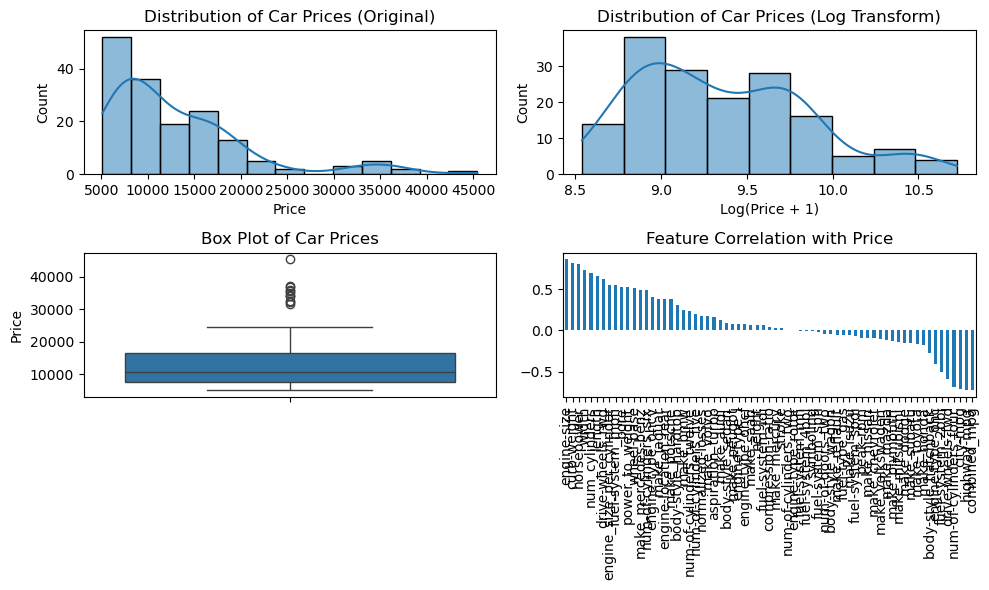

In [3]:
# Feature statistics
print("\nFeature Statistics:")
display(x_train.describe())

# Target statistics
print("\nTarget Statistics:")
display(y_train.describe())

# Check for outliers in the target variable
Q1 = y_train['price'].quantile(0.25)
Q3 = y_train['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Potential outliers in target: {((y_train['price'] < lower_bound) | (y_train['price'] > upper_bound)).sum()}")

# Visualize distribution and transformations
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(y_train['price'], kde=True)
plt.title('Distribution of Car Prices (Original)')
plt.xlabel('Price')

# Log transform for skewed price distribution
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(y_train['price']), kde=True)
plt.title('Distribution of Car Prices (Log Transform)')
plt.xlabel('Log(Price + 1)')

# Boxplot to visualize outliers
plt.subplot(2, 2, 3)
sns.boxplot(y=y_train['price'])
plt.title('Box Plot of Car Prices')
plt.ylabel('Price')

# Feature correlation analysis
plt.subplot(2, 2, 4)
correlation = x_train.corrwith(y_train['price']).sort_values(ascending=False)
correlation.plot(kind='bar', figsize=(10, 6))
plt.title('Feature Correlation with Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Preprocessing

In [4]:
# Handle outliers in target (capping extreme values)
y_train_processed = y_train.copy()
y_train_processed['price'] = np.where(y_train['price'] > upper_bound, upper_bound, 
                              np.where(y_train['price'] < lower_bound, lower_bound, y_train['price']))

# Feature selection
selector = SelectKBest(f_regression, k='all')
selector.fit(x_train, y_train_processed['price'])
feature_scores = pd.DataFrame({'Feature': x_train.columns, 'Score': selector.scores_})
top_features = feature_scores.sort_values('Score', ascending=False)
print("\nTop 10 important features:")
display(top_features.head(10))

# Create polynomial features for top numerical features
# Identify top numerical features
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns
top_num_features = [col for col in top_features['Feature'].head(5) if col in numerical_features]

# Create a copy of the datasets for feature engineering
x_train_fe = x_train.copy()
x_test_fe = x_test.copy()

for feature in top_num_features:
    x_train_fe[f'{feature}_squared'] = x_train_fe[feature] ** 2
    x_test_fe[f'{feature}_squared'] = x_test_fe[feature] ** 2

# Add interaction terms between top features
if len(top_num_features) >= 2:
    for i in range(len(top_num_features)-1):
        for j in range(i+1, len(top_num_features)):
            feat1, feat2 = top_num_features[i], top_num_features[j]
            x_train_fe[f'{feat1}_x_{feat2}'] = x_train_fe[feat1] * x_train_fe[feat2]
            x_test_fe[f'{feat1}_x_{feat2}'] = x_test_fe[feat1] * x_test_fe[feat2]

print(f"Features after engineering: {x_train_fe.shape[1]}")

# Scaling and transformations
# Standard scaling
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(x_train_fe)
X_test_scaled = scaler_standard.transform(x_test_fe)

# Power transform for potentially better handling of skewed features
power_transformer = PowerTransformer(method='yeo-johnson')
X_train_power = power_transformer.fit_transform(x_train_fe)
X_test_power = power_transformer.transform(x_test_fe)

# Robust scaling (less sensitive to outliers)
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(x_train_fe)
X_test_robust = robust_scaler.transform(x_test_fe)

# For target, try both regular and log transform scaling
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_processed)
y_test_scaled = y_scaler.transform(y_test)

# Log transform version
y_train_log = np.log1p(y_train_processed)
y_test_log = np.log1p(y_test)
y_log_scaler = StandardScaler()
y_train_log_scaled = y_log_scaler.fit_transform(y_train_log)
y_test_log_scaled = y_log_scaler.transform(y_test_log)


Top 10 important features:


,Feature,Score
6,curb-weight,417.126308
7,engine-size,355.022676
11,horsepower,323.655484
4,width,209.455501
18,combined_mpg,206.712397
14,highway-mpg,202.571134
13,city-mpg,195.206119
3,length,152.968420
56,num-of-cylinders_four,149.498621
48,drive-wheels_rwd,125.362874


Features after engineering: 82


## 5. Custom Callbacks and Helpers for Model Training

In [5]:
# Custom callback to save best weights in memory to avoid TensorFlow model loading issues
class BestWeightsCallback(tf.keras.callbacks.Callback):
    def __init__(self, monitor='val_loss', mode='min'):
        super(BestWeightsCallback, self).__init__()
        self.monitor = monitor
        self.best_weights = None
        self.best_epoch = 0
        self.mode = mode
        if mode == 'min':
            self.best = float('inf')
            self.monitor_op = lambda a, b: a < b
        else:  # 'max'
            self.best = float('-inf')
            self.monitor_op = lambda a, b: a > b

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        
        if self.monitor_op(current, self.best):
            self.best = current
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()
            print(f'\nEpoch {epoch+1}: New best {self.monitor} = {current:.6f}')

# Training utility function
def train_model(X_train, y_train, X_val, y_val, model, 
                batch_size=32, epochs=500, optimizer='adam', learning_rate=0.001,
                loss='mse', patience=15):
    
    # Best weights callback
    best_weights_callback = BestWeightsCallback(monitor='val_loss', mode='min')
    
    # Define callbacks
    callbacks = [
        # Early stopping
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            verbose=1,
            min_delta=0.0001
        ),
        # Reduce learning rate when training plateaus
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            verbose=1,
            min_delta=0.0001,
            min_lr=1e-6
        ),
        # Custom callback to track best weights
        best_weights_callback
    ]
    
    # Configure optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)
    
    # Configure loss function
    if loss == 'mse':
        loss_fn = MeanSquaredError()
    elif loss == 'mae':
        loss_fn = MeanAbsoluteError()
    elif loss == 'huber':
        loss_fn = Huber(delta=1.0)
    
    # Compile model
    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[RootMeanSquaredError()]
    )
    
    # Train model
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Restore best weights
    if best_weights_callback.best_weights is not None:
        print(f"Restoring best weights from epoch {best_weights_callback.best_epoch}")
        model.set_weights(best_weights_callback.best_weights)
    
    return model, history, training_time

## 6. Neural Architecture Search

In [6]:
# Split validation set
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=42
)

# For log-transformed target
_, _, y_train_log_main, y_val_log = train_test_split(
    X_train_scaled, y_train_log_scaled, test_size=0.15, random_state=42
)

# Define architecture search space
def create_model_architecture(input_dim, architecture_params):
    model = Sequential()
    
    # First layer always includes input shape
    model.add(Dense(architecture_params['layer_sizes'][0], input_shape=(input_dim,)))
    
    # Add batch normalization if specified
    if architecture_params['use_batch_norm']:
        model.add(BatchNormalization())
        
    # Add activation
    if architecture_params['activation'] == 'leaky_relu':
        model.add(LeakyReLU(alpha=0.1))
    elif architecture_params['activation'] == 'prelu':
        model.add(PReLU())
    else:  # Regular ReLU
        model.add(tf.keras.layers.Activation('relu'))
    
    # Add dropout if rate > 0
    if architecture_params['dropout_rates'][0] > 0:
        model.add(Dropout(architecture_params['dropout_rates'][0]))
    
    # Add remaining hidden layers
    for i in range(1, len(architecture_params['layer_sizes'])):
        reg = None
        if architecture_params['use_regularization']:
            reg = l1_l2(l1=1e-5, l2=1e-4)
            
        model.add(Dense(architecture_params['layer_sizes'][i], kernel_regularizer=reg))
        
        if architecture_params['use_batch_norm']:
            model.add(BatchNormalization())
            
        if architecture_params['activation'] == 'leaky_relu':
            model.add(LeakyReLU(alpha=0.1))
        elif architecture_params['activation'] == 'prelu':
            model.add(PReLU())
        else:  # Regular ReLU
            model.add(tf.keras.layers.Activation('relu'))
        
        if i < len(architecture_params['dropout_rates']) and architecture_params['dropout_rates'][i] > 0:
            model.add(Dropout(architecture_params['dropout_rates'][i]))
    
    # Output layer
    model.add(Dense(1))
    
    return model

# Define architectures to try
architecture_search_space = [
    {
        'name': 'Small Network',
        'layer_sizes': [64, 32],
        'dropout_rates': [0.2, 0.1],
        'activation': 'relu',
        'use_batch_norm': False,
        'use_regularization': False
    },
    {
        'name': 'Medium Network with Regularization',
        'layer_sizes': [128, 64, 32],
        'dropout_rates': [0.3, 0.3, 0.2],
        'activation': 'relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'Deep Network',
        'layer_sizes': [256, 128, 64, 32],
        'dropout_rates': [0.4, 0.3, 0.3, 0.2],
        'activation': 'leaky_relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'Wide Network',
        'layer_sizes': [512, 256, 128],
        'dropout_rates': [0.5, 0.4, 0.3],
        'activation': 'leaky_relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'PReLU Network',
        'layer_sizes': [256, 128, 64],
        'dropout_rates': [0.4, 0.3, 0.2],
        'activation': 'prelu',
        'use_batch_norm': True,
        'use_regularization': True
    }
]

# Training parameters to try
training_params = [
    {'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'mse'},
    {'optimizer': 'adam', 'learning_rate': 0.0005, 'batch_size': 64, 'loss': 'mse'},
    {'optimizer': 'rmsprop', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'mse'},
    {'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'huber'}
]

# Target transformation options
target_options = [
    {'name': 'Standard Scaled', 'X_train': X_train_main, 'y_train': y_train_main, 
     'X_val': X_val, 'y_val': y_val, 'X_test': X_test_scaled, 'y_test': y_test_scaled,
     'inverse_func': lambda y: y_scaler.inverse_transform(y)},
    
    {'name': 'Log Transformed', 'X_train': X_train_main, 'y_train': y_train_log_main,
     'X_val': X_val, 'y_val': y_val_log, 'X_test': X_test_scaled, 'y_test': y_test_log_scaled,
     'inverse_func': lambda y: np.expm1(y_log_scaler.inverse_transform(y))}
]

## 7. Run Architecture Search



Training: Standard Scaled + Small Network + adam (lr=0.001) + mse


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-10 17:20:29.286298: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 675ms/step - loss: 1.7350 - root_mean_squared_error: 1.3172
Epoch 1: New best val_loss = 0.570468
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.3506 - root_mean_squared_error: 1.1598 - val_loss: 0.5705 - val_root_mean_squared_error: 0.7553 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0302 - root_mean_squared_error: 1.0150
Epoch 2: New best val_loss = 0.426070
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9695 - root_mean_squared_error: 0.9844 - val_loss: 0.4261 - val_root_mean_squared_error: 0.6527 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6344 - root_mean_squared_error: 0.7965
Epoch 3: New best val_loss = 0.411473
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5293 - root_mean_squared_error: 0.7266 - val_loss: 0.4115 - val_root_mean_squared_error: 0.6415 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.9531 - root_mean_squared

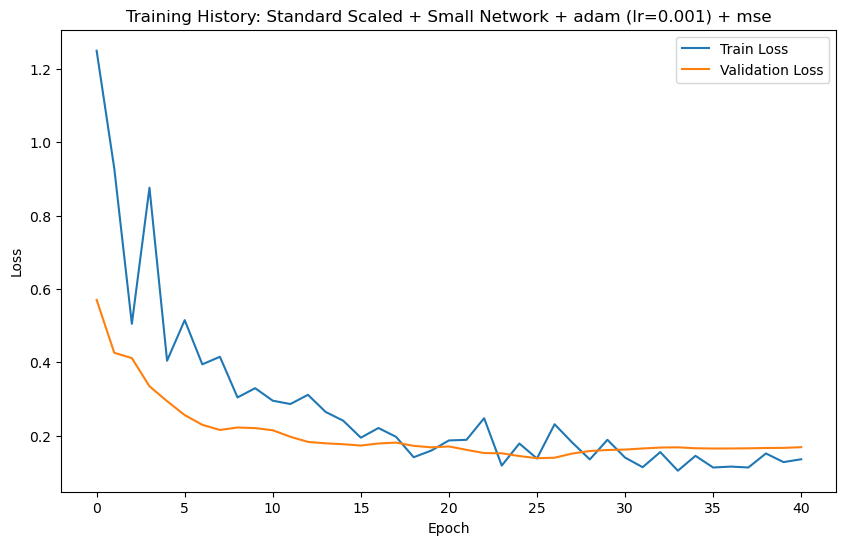



Training: Standard Scaled + Small Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step - loss: 1.7760 - root_mean_squared_error: 1.3327
Epoch 1: New best val_loss = 0.807666
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 1.6013 - root_mean_squared_error: 1.2648 - val_loss: 0.8077 - val_root_mean_squared_error: 0.8987 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5134 - root_mean_squared_error: 1.2302
Epoch 2: New best val_loss = 0.708212
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.3755 - root_mean_squared_error: 1.1723 - val_loss: 0.7082 - val_root_mean_squared_error: 0.8416 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2899 - root_mean_squared_error: 1.1357
Epoch 3: New best val_loss = 0.632891
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1430 - root_mean_squared_error: 1.0684 - val_loss: 0.6329 - val_root_mean_squared_error: 0.7955 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.6759 - root_mean_squared

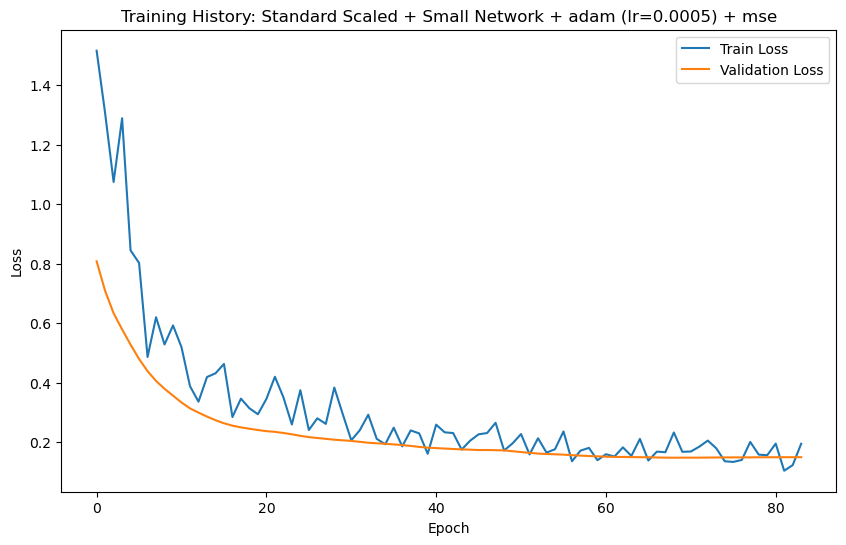



Training: Standard Scaled + Small Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - loss: 2.9180 - root_mean_squared_error: 1.7082
Epoch 1: New best val_loss = 1.153258
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 2.0888 - root_mean_squared_error: 1.4386 - val_loss: 1.1533 - val_root_mean_squared_error: 1.0739 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1591 - root_mean_squared_error: 1.0766
Epoch 2: New best val_loss = 0.834399
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8895 - root_mean_squared_error: 0.9407 - val_loss: 0.8344 - val_root_mean_squared_error: 0.9135 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6523 - root_mean_squared_error: 0.8076
Epoch 3: New best val_loss = 0.649850
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5807 - root_mean_squared_error: 0.7616 - val_loss: 0.6498 - val_root_mean_squared_error: 0.8061 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3199 - root_mean_squared_error: 1.14

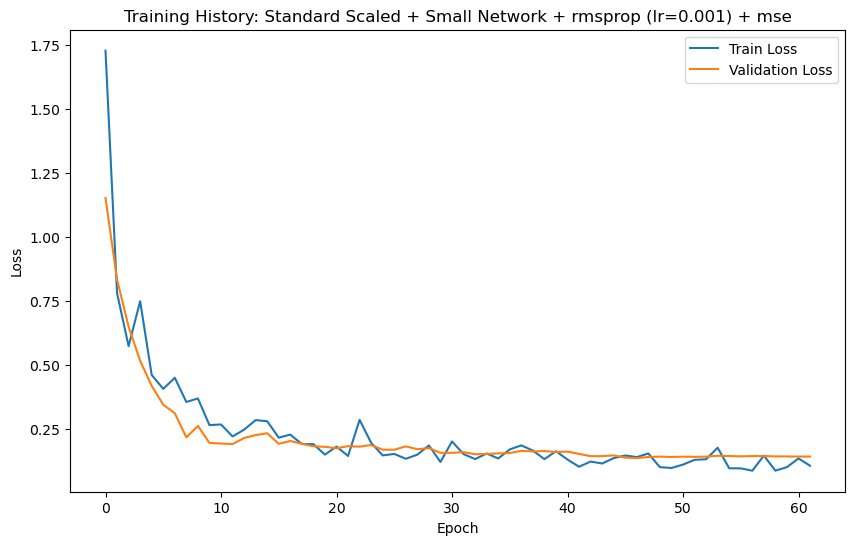



Training: Standard Scaled + Small Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 719ms/step - loss: 0.8328 - root_mean_squared_error: 1.4775
Epoch 1: New best val_loss = 0.342323
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.7165 - root_mean_squared_error: 1.3593 - val_loss: 0.3423 - val_root_mean_squared_error: 0.8548 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5787 - root_mean_squared_error: 1.4063
Epoch 2: New best val_loss = 0.145088
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4739 - root_mean_squared_error: 1.1789 - val_loss: 0.1451 - val_root_mean_squared_error: 0.5387 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3434 - root_mean_squared_error: 0.8751
Epoch 3: New best val_loss = 0.078842
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3151 - root_mean_squared_error: 0.8699 - val_loss: 0.0788 - val_root_mean_squared_error: 0.3971 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4066 - root_mean_squared_error: 1.15

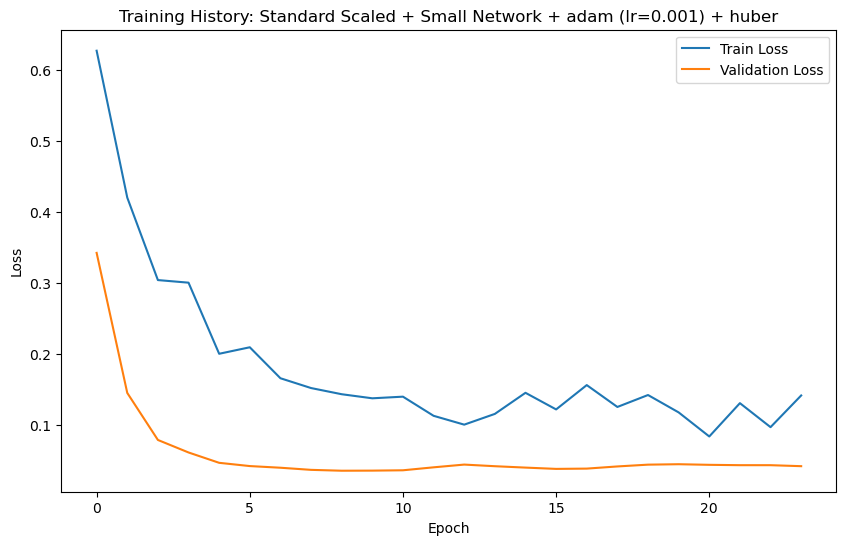



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.6952 - root_mean_squared_error: 1.2933
Epoch 1: New best val_loss = 0.586414
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 1.6507 - root_mean_squared_error: 1.2756 - val_loss: 0.5864 - val_root_mean_squared_error: 0.7509 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0268 - root_mean_squared_error: 1.0021
Epoch 2: New best val_loss = 0.508691
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2925 - root_mean_squared_error: 1.1253 - val_loss: 0.5087 - val_root_mean_squared_error: 0.6972 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7779 - root_mean_squared_error: 0.8691
Epoch 3: New best val_loss = 0.472718
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9471 - root_mean_squared_error: 0.9606 - val_loss: 0.4727 - val_root_mean_squared_error: 0.6709 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1916 - root_mean_squared_error: 1.0812


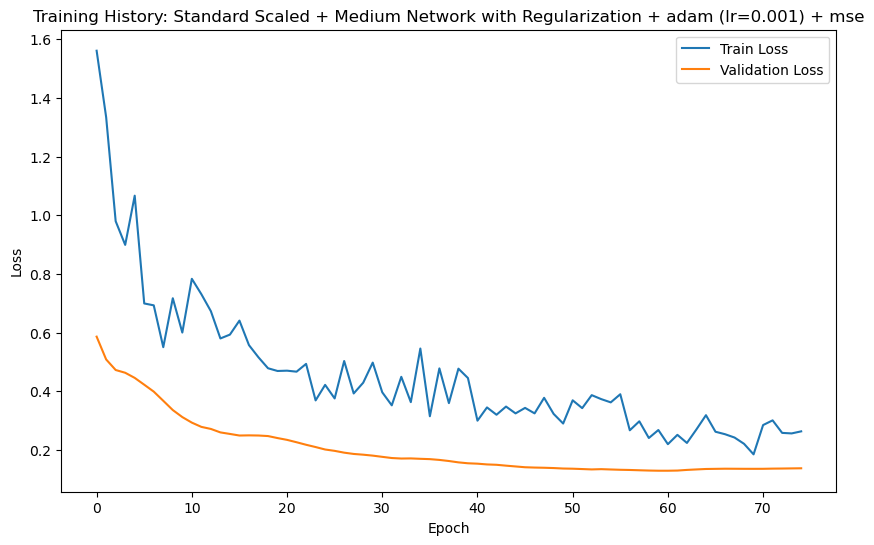



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 4.2259 - root_mean_squared_error: 2.0502
Epoch 1: New best val_loss = 0.859370
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 4.5329 - root_mean_squared_error: 2.1233 - val_loss: 0.8594 - val_root_mean_squared_error: 0.9148 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.9725 - root_mean_squared_error: 1.9874
Epoch 2: New best val_loss = 0.745748
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.0764 - root_mean_squared_error: 2.0133 - val_loss: 0.7457 - val_root_mean_squared_error: 0.8504 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.8107 - root_mean_squared_error: 1.9463
Epoch 3: New best val_loss = 0.643296
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.8508 - root_mean_squared_error: 1.9566 - val_loss: 0.6433 - val_root_mean_squared_error: 0.7879 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.3569 - root_mean_squared_er

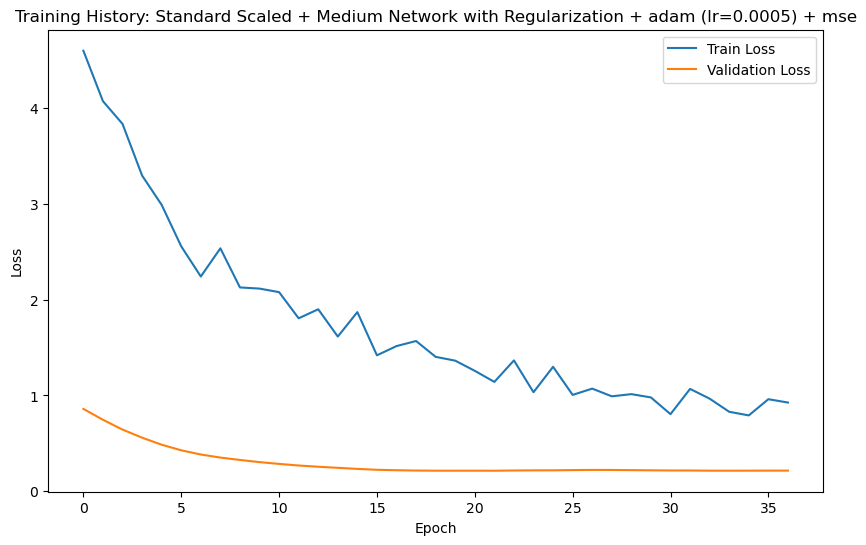



Training: Standard Scaled + Medium Network with Regularization + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 2.3694 - root_mean_squared_error: 1.5319
Epoch 1: New best val_loss = 1.098730
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.8900 - root_mean_squared_error: 1.3639 - val_loss: 1.0987 - val_root_mean_squared_error: 1.0374 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9099 - root_mean_squared_error: 0.9420
Epoch 2: New best val_loss = 0.903885
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3434 - root_mean_squared_error: 1.1449 - val_loss: 0.9039 - val_root_mean_squared_error: 0.9388 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7463 - root_mean_squared_error: 0.8507
Epoch 3: New best val_loss = 0.766236
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0008 - root_mean_squared_error: 0.9871 - val_loss: 0.7662 - val_root_mean_squared_error: 0.8623 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8541 - root_mean_squared_error: 0.9119


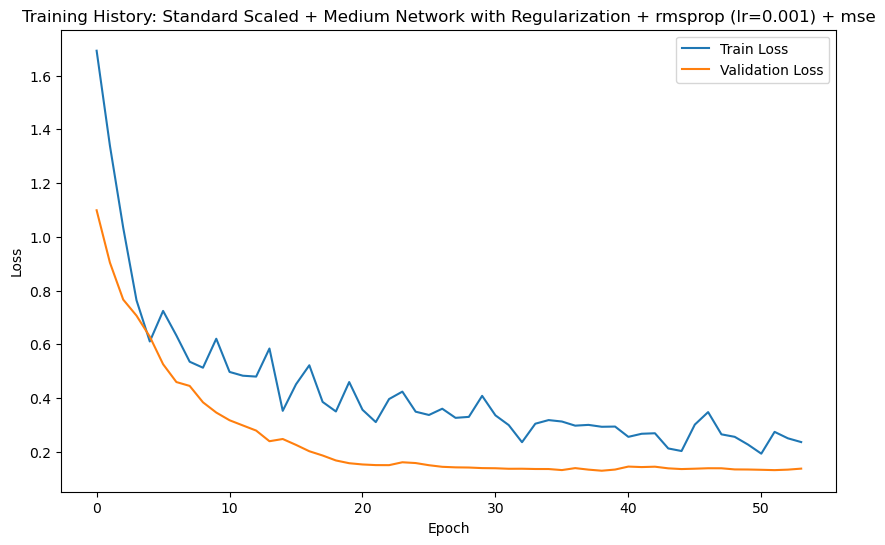



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.1375 - root_mean_squared_error: 1.9951
Epoch 1: New best val_loss = 0.298447
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.9148 - root_mean_squared_error: 1.6821 - val_loss: 0.2984 - val_root_mean_squared_error: 0.7591 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6255 - root_mean_squared_error: 1.2587
Epoch 2: New best val_loss = 0.263929
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5742 - root_mean_squared_error: 1.1858 - val_loss: 0.2639 - val_root_mean_squared_error: 0.7029 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6740 - root_mean_squared_error: 1.2969
Epoch 3: New best val_loss = 0.242748
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5905 - root_mean_squared_error: 1.2035 - val_loss: 0.2427 - val_root_mean_squared_error: 0.6685 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4074 - root_mean_squared_error: 1.0211


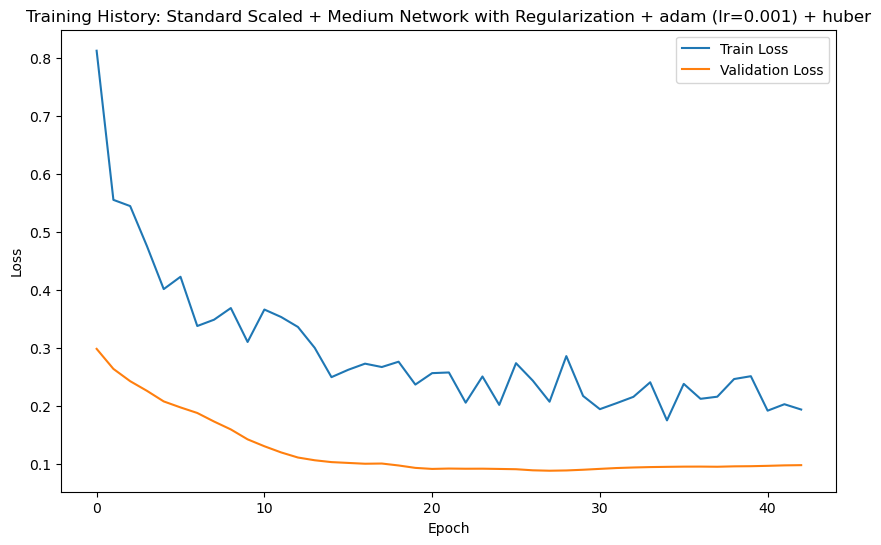



Training: Standard Scaled + Deep Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 2.1464 - root_mean_squared_error: 1.4443
Epoch 1: New best val_loss = 0.548427
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 1.5614 - root_mean_squared_error: 1.2200 - val_loss: 0.5484 - val_root_mean_squared_error: 0.6986 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9156 - root_mean_squared_error: 0.9248
Epoch 2: New best val_loss = 0.484154
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0513 - root_mean_squared_error: 0.9949 - val_loss: 0.4842 - val_root_mean_squared_error: 0.6509 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6723 - root_mean_squared_error: 0.7822
Epoch 3: New best val_loss = 0.405045
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0309 - root_mean_squared_error: 0.9808 - val_loss: 0.4050 - val_root_mean_squared_error: 0.5870 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7054 - root_mean_squared_error: 0.8031


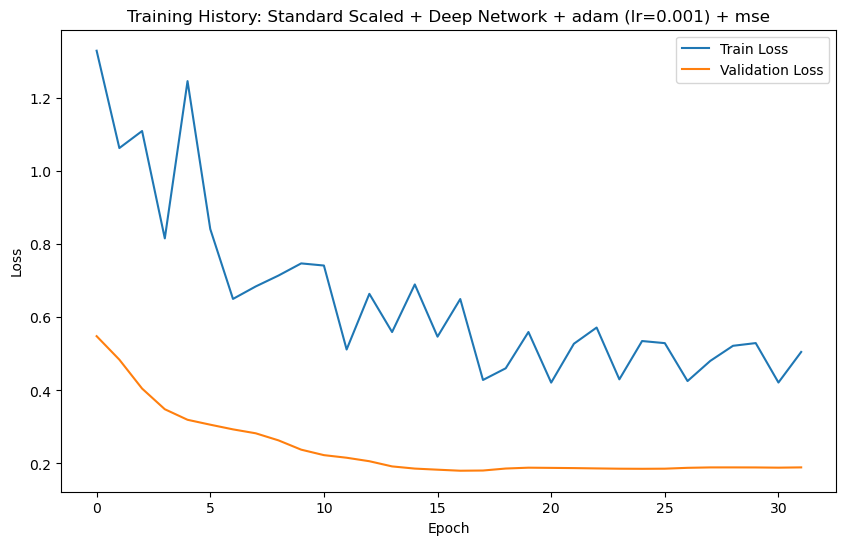



Training: Standard Scaled + Deep Network + adam (lr=0.0005) + mse


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 1.3488 - root_mean_squared_error: 1.1352
Epoch 1: New best val_loss = 0.635212
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 1.6332 - root_mean_squared_error: 1.2524 - val_loss: 0.6352 - val_root_mean_squared_error: 0.7584 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.5513 - root_mean_squared_error: 1.2212
Epoch 2: New best val_loss = 0.616442
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5502 - root_mean_squared_error: 1.2207 - val_loss: 0.6164 - val_root_mean_squared_error: 0.7459 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.6937 - root_mean_squared_error: 1.2781
Epoch 3: New best val_loss = 0.593924
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.5877 - root_mean_squared_error: 1.2357 - val_loss: 0.5939 - val_root_mean_squared_error: 0.7306 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7937 - root_me

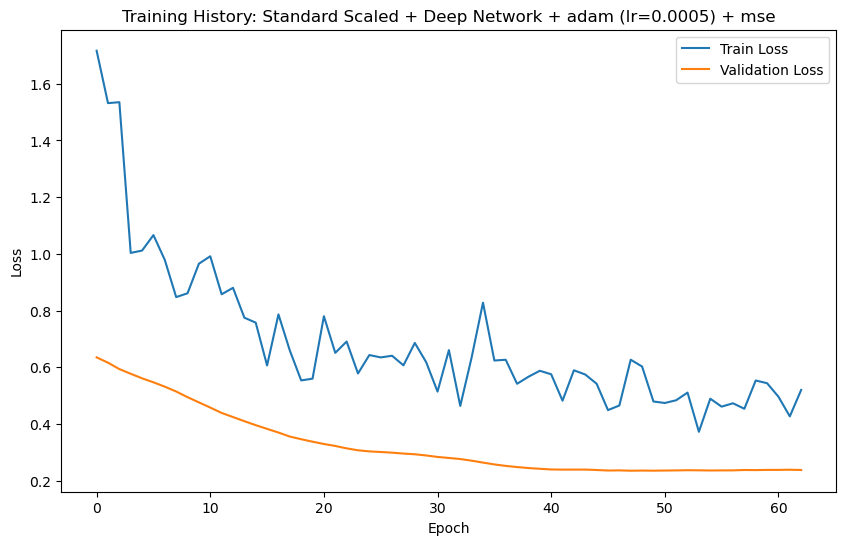



Training: Standard Scaled + Deep Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.9144 - root_mean_squared_error: 1.3618
Epoch 1: New best val_loss = 0.774544
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 1.9033 - root_mean_squared_error: 1.3576 - val_loss: 0.7745 - val_root_mean_squared_error: 0.8452 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.3175 - root_mean_squared_error: 1.1213
Epoch 2: New best val_loss = 0.487733
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2474 - root_mean_squared_error: 1.0894 - val_loss: 0.4877 - val_root_mean_squared_error: 0.6539 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2649 - root_mean_squared_error: 1.0976
Epoch 3: New best val_loss = 0.456508
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3333 - root_mean_squared_error: 1.1268 - val_loss: 0.4565 - val_root_mean_squared_error: 0.6295 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1533 - root_mean_squared_error: 1.0455


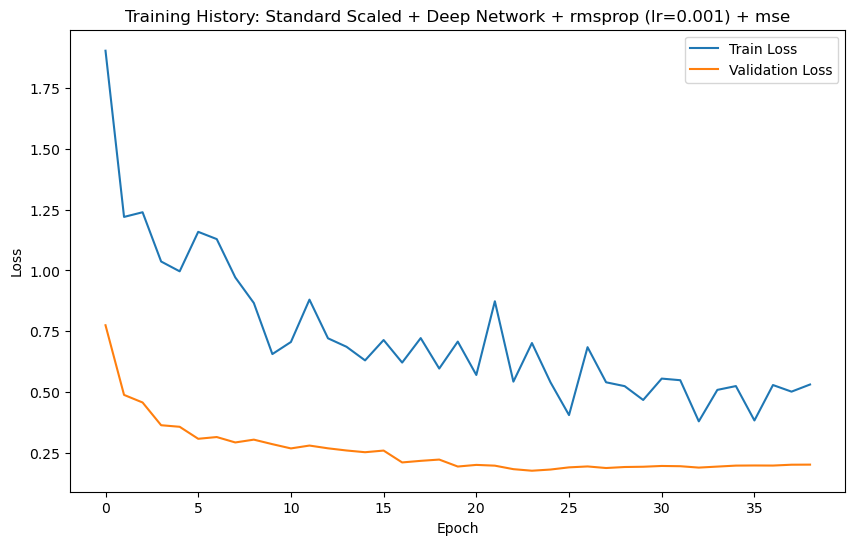



Training: Standard Scaled + Deep Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.7872 - root_mean_squared_error: 1.3519
Epoch 1: New best val_loss = 0.531872
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.7547 - root_mean_squared_error: 1.3468 - val_loss: 0.5319 - val_root_mean_squared_error: 0.9983 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7361 - root_mean_squared_error: 1.2965
Epoch 2: New best val_loss = 0.433486
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6629 - root_mean_squared_error: 1.2509 - val_loss: 0.4335 - val_root_mean_squared_error: 0.8811 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5109 - root_mean_squared_error: 1.0395
Epoch 3: New best val_loss = 0.345926
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5297 - root_mean_squared_error: 1.0898 - val_loss: 0.3459 - val_root_mean_squared_error: 0.7670 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5928 - root_mean_squared_error: 1.2293


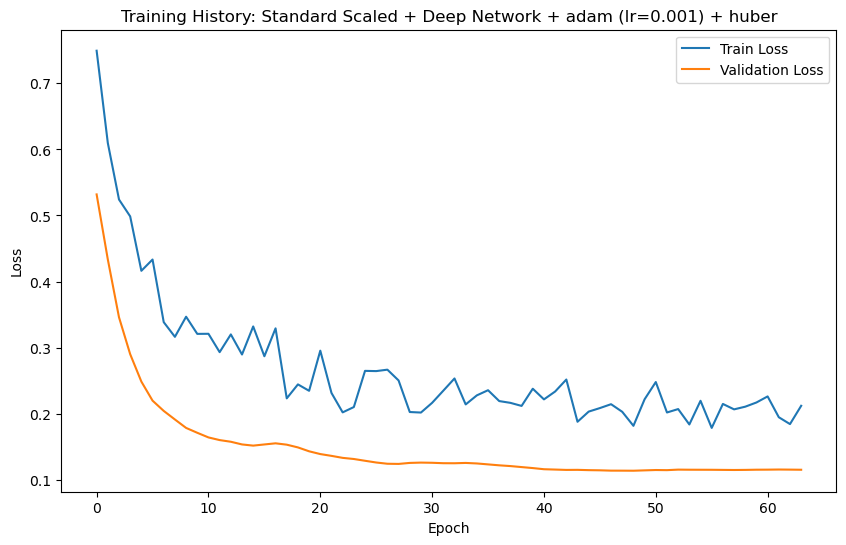



Training: Standard Scaled + Wide Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 3.2320 - root_mean_squared_error: 1.7613
Epoch 1: New best val_loss = 0.466823
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 2.3048 - root_mean_squared_error: 1.4669 - val_loss: 0.4668 - val_root_mean_squared_error: 0.5805 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.3689 - root_mean_squared_error: 1.1131
Epoch 2: New best val_loss = 0.378199
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2619 - root_mean_squared_error: 1.0631 - val_loss: 0.3782 - val_root_mean_squared_error: 0.4982 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9447 - root_mean_squared_error: 0.9022 - val_loss: 0.3786 - val_root_mean_squared_error: 0.4984 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9406 - root_mean_squared_error: 0.8991 - val_loss: 0.4134 - val_root_mean_squared_error: 0.5320 - learning_rate: 0.0010
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms

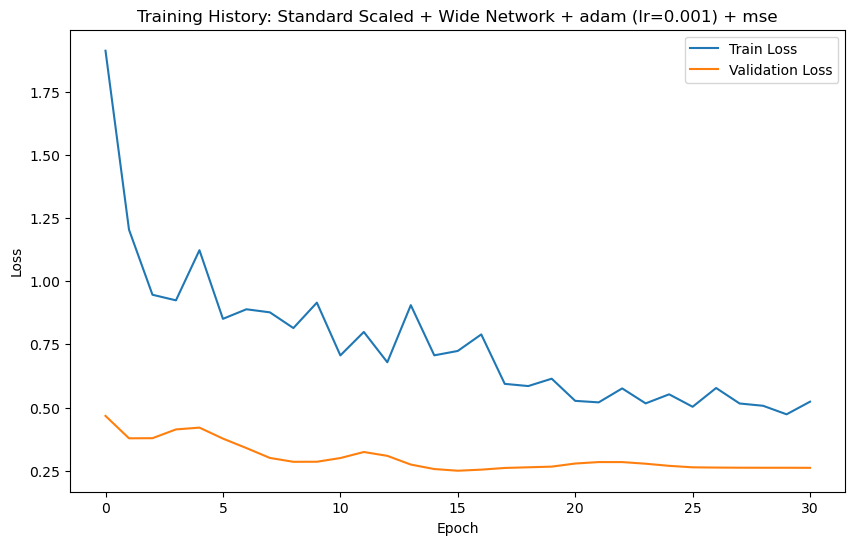



Training: Standard Scaled + Wide Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 2.9097 - root_mean_squared_error: 1.6673
Epoch 1: New best val_loss = 0.551639
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 2.7855 - root_mean_squared_error: 1.6294 - val_loss: 0.5516 - val_root_mean_squared_error: 0.6494 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.5200 - root_mean_squared_error: 1.5460
Epoch 2: New best val_loss = 0.486745
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.0331 - root_mean_squared_error: 1.3760 - val_loss: 0.4867 - val_root_mean_squared_error: 0.5973 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9905 - root_mean_squared_error: 0.9277
Epoch 3: New best val_loss = 0.457865
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0429 - root_mean_squared_error: 0.9553 - val_loss: 0.4579 - val_root_mean_squared_error: 0.5726 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1847 - root_mean_squared_e

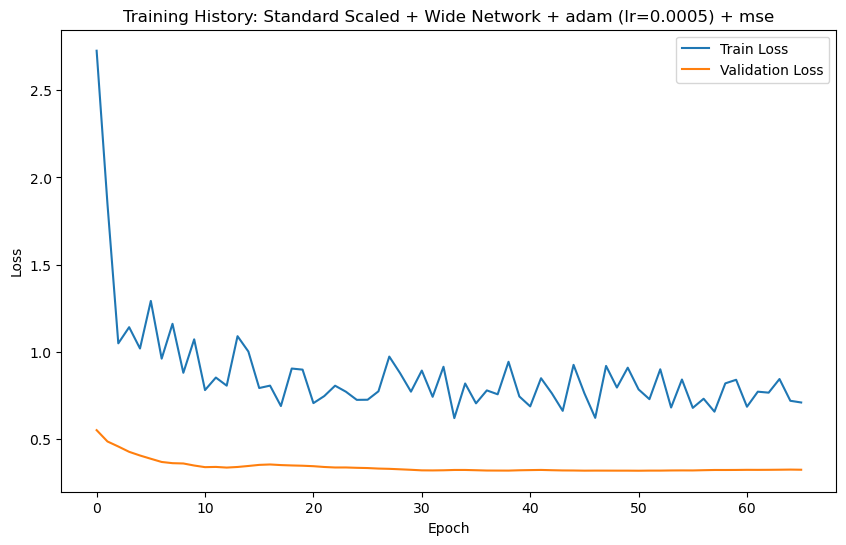



Training: Standard Scaled + Wide Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.0883 - root_mean_squared_error: 1.3995
Epoch 1: New best val_loss = 0.671068
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 1.6318 - root_mean_squared_error: 1.2224 - val_loss: 0.6711 - val_root_mean_squared_error: 0.7354 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.4560 - root_mean_squared_error: 1.1514
Epoch 2: New best val_loss = 0.428288
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2845 - root_mean_squared_error: 1.0735 - val_loss: 0.4283 - val_root_mean_squared_error: 0.5458 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9831 - root_mean_squared_error: 0.9234
Epoch 3: New best val_loss = 0.331635
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1179 - root_mean_squared_error: 0.9930 - val_loss: 0.3316 - val_root_mean_squared_error: 0.4485 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0903 - root_mean_squared_error: 0.9776 

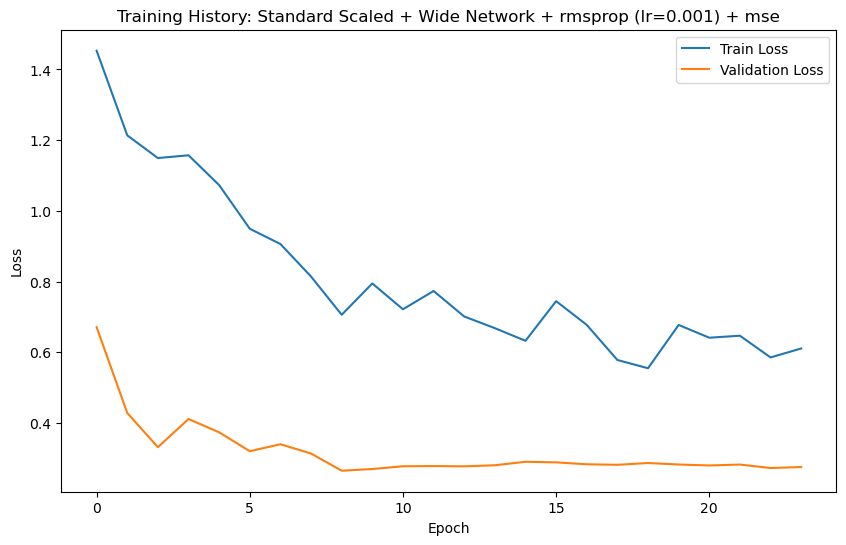



Training: Standard Scaled + Wide Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.7080 - root_mean_squared_error: 1.2218
Epoch 1: New best val_loss = 0.385239
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.7034 - root_mean_squared_error: 1.2303 - val_loss: 0.3852 - val_root_mean_squared_error: 0.7222 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6589 - root_mean_squared_error: 1.2419
Epoch 2: New best val_loss = 0.325920
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6502 - root_mean_squared_error: 1.2176 - val_loss: 0.3259 - val_root_mean_squared_error: 0.6312 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5633 - root_mean_squared_error: 1.0519
Epoch 3: New best val_loss = 0.297269
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6331 - root_mean_squared_error: 1.1265 - val_loss: 0.2973 - val_root_mean_squared_error: 0.5815 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4978 - root_mean_squared_error: 0.9026


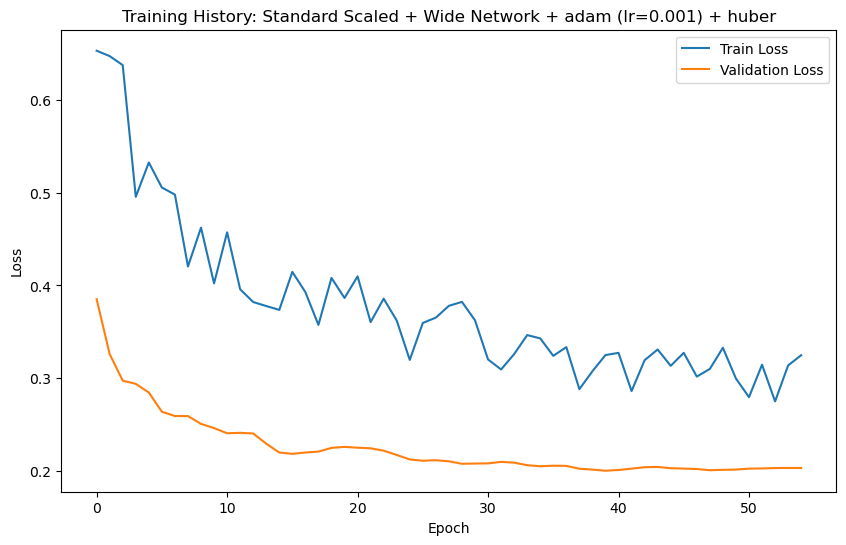



Training: Standard Scaled + PReLU Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 4.8021 - root_mean_squared_error: 2.1791
Epoch 1: New best val_loss = 0.564615
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 4.0117 - root_mean_squared_error: 1.9875 - val_loss: 0.5646 - val_root_mean_squared_error: 0.7149 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1542 - root_mean_squared_error: 1.4494
Epoch 2: New best val_loss = 0.427079
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.5056 - root_mean_squared_error: 1.5650 - val_loss: 0.4271 - val_root_mean_squared_error: 0.6111 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3655 - root_mean_squared_error: 1.1454
Epoch 3: New best val_loss = 0.391945
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3965 - root_mean_squared_error: 1.1583 - val_loss: 0.3919 - val_root_mean_squared_error: 0.5816 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1331 - root_mean_squared_error: 1.0355 

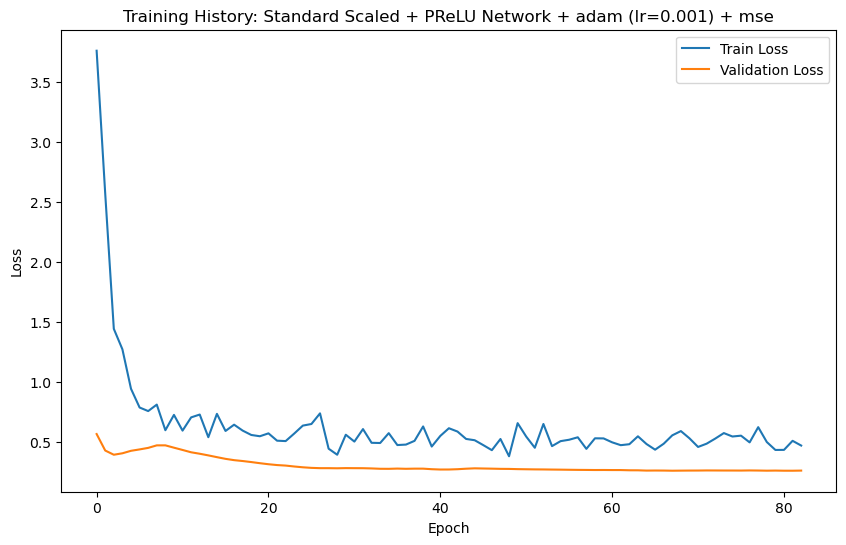



Training: Standard Scaled + PReLU Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 4.7785 - root_mean_squared_error: 2.1738
Epoch 1: New best val_loss = 0.778404
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 4.2590 - root_mean_squared_error: 2.0495 - val_loss: 0.7784 - val_root_mean_squared_error: 0.8515 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.8227 - root_mean_squared_error: 1.6642
Epoch 2: New best val_loss = 0.608523
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.5457 - root_mean_squared_error: 1.5778 - val_loss: 0.6085 - val_root_mean_squared_error: 0.7451 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5348 - root_mean_squared_error: 1.2172
Epoch 3: New best val_loss = 0.483169
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.7368 - root_mean_squared_error: 1.2967 - val_loss: 0.4832 - val_root_mean_squared_error: 0.6556 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.0540 - root_mean_squared_e

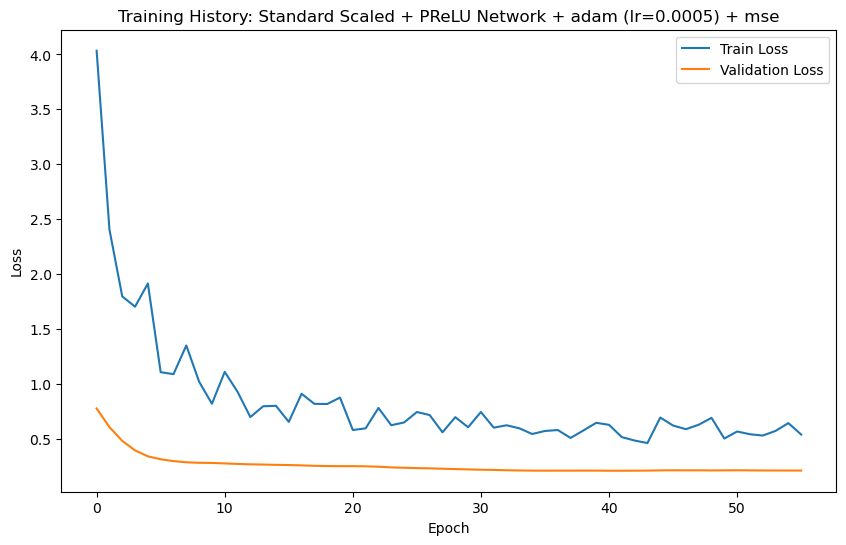



Training: Standard Scaled + PReLU Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 1.6668 - root_mean_squared_error: 1.2702
Epoch 1: New best val_loss = 0.358738
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 1.4412 - root_mean_squared_error: 1.1757 - val_loss: 0.3587 - val_root_mean_squared_error: 0.5526 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9509 - root_mean_squared_error: 0.9474
Epoch 2: New best val_loss = 0.295044
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8571 - root_mean_squared_error: 0.8960 - val_loss: 0.2950 - val_root_mean_squared_error: 0.4916 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9480 - root_mean_squared_error: 0.9441 - val_loss: 0.3051 - val_root_mean_squared_error: 0.5016 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7033 - root_mean_squared_error: 0.8062
Epoch 4: New best val_loss = 0.282025
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7080 - root_mean_squared_error: 0.8090 

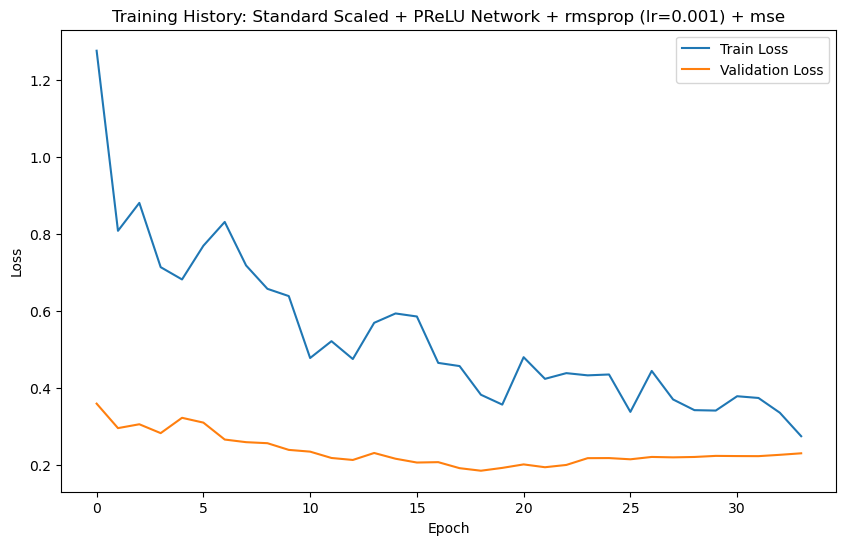



Training: Standard Scaled + PReLU Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.7154 - root_mean_squared_error: 1.3303
Epoch 1: New best val_loss = 0.379990
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.6978 - root_mean_squared_error: 1.3301 - val_loss: 0.3800 - val_root_mean_squared_error: 0.8217 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3135 - root_mean_squared_error: 0.7988
Epoch 2: New best val_loss = 0.372675
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4280 - root_mean_squared_error: 0.9397 - val_loss: 0.3727 - val_root_mean_squared_error: 0.8057 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3509 - root_mean_squared_error: 0.8351
Epoch 3: New best val_loss = 0.366240
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3719 - root_mean_squared_error: 0.8511 - val_loss: 0.3662 - val_root_mean_squared_error: 0.7984 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3945 - root_mean_squared_error: 1.1014


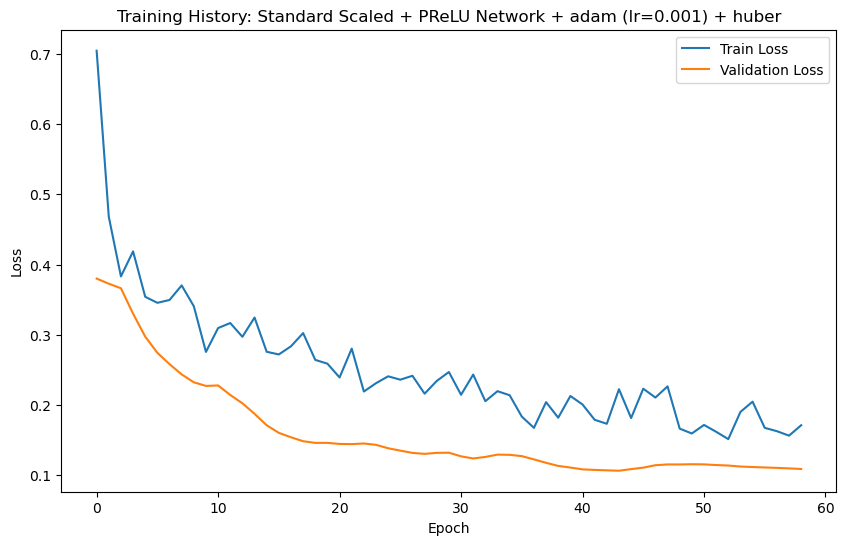



Training: Log Transformed + Small Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 673ms/step - loss: 1.1633 - root_mean_squared_error: 1.0786
Epoch 1: New best val_loss = 0.585865
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.0678 - root_mean_squared_error: 1.0330 - val_loss: 0.5859 - val_root_mean_squared_error: 0.7654 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8318 - root_mean_squared_error: 0.9120
Epoch 2: New best val_loss = 0.444142
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8343 - root_mean_squared_error: 0.9127 - val_loss: 0.4441 - val_root_mean_squared_error: 0.6664 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6692 - root_mean_squared_error: 0.8180
Epoch 3: New best val_loss = 0.356941
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6012 - root_mean_squared_error: 0.7750 - val_loss: 0.3569 - val_root_mean_squared_error: 0.5974 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8692 - root_mean_squared_error: 0.93

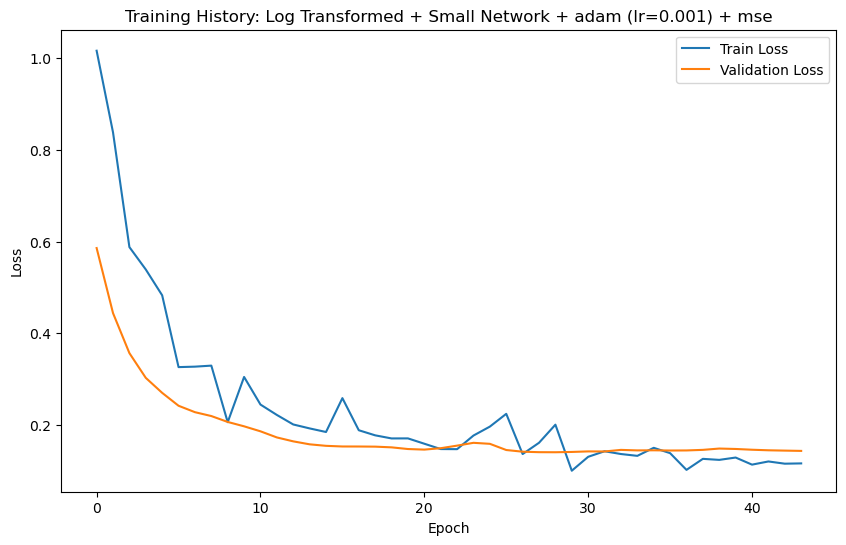



Training: Log Transformed + Small Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step - loss: 2.0990 - root_mean_squared_error: 1.4488
Epoch 1: New best val_loss = 1.113504
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 1.8235 - root_mean_squared_error: 1.3491 - val_loss: 1.1135 - val_root_mean_squared_error: 1.0552 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2732 - root_mean_squared_error: 1.1284
Epoch 2: New best val_loss = 0.879685
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.3190 - root_mean_squared_error: 1.1484 - val_loss: 0.8797 - val_root_mean_squared_error: 0.9379 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1061 - root_mean_squared_error: 1.0517
Epoch 3: New best val_loss = 0.706778
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.2298 - root_mean_squared_error: 1.1085 - val_loss: 0.7068 - val_root_mean_squared_error: 0.8407 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9341 - root_mean_squared

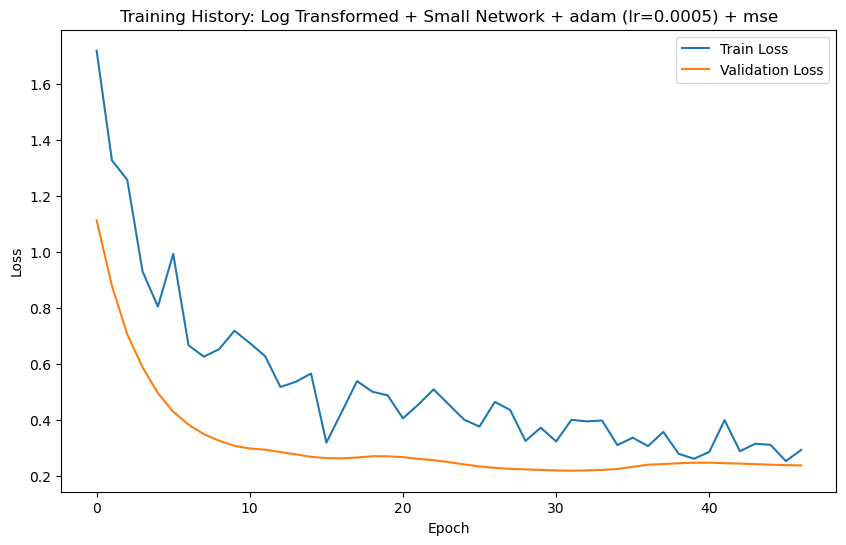



Training: Log Transformed + Small Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step - loss: 1.6226 - root_mean_squared_error: 1.2738
Epoch 1: New best val_loss = 0.647607
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 1.3513 - root_mean_squared_error: 1.1605 - val_loss: 0.6476 - val_root_mean_squared_error: 0.8047 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9090 - root_mean_squared_error: 0.9534
Epoch 2: New best val_loss = 0.428003
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7765 - root_mean_squared_error: 0.8803 - val_loss: 0.4280 - val_root_mean_squared_error: 0.6542 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6465 - root_mean_squared_error: 0.8041
Epoch 3: New best val_loss = 0.338534
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5200 - root_mean_squared_error: 0.7197 - val_loss: 0.3385 - val_root_mean_squared_error: 0.5818 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1405 - root_mean_squared_error: 1.06

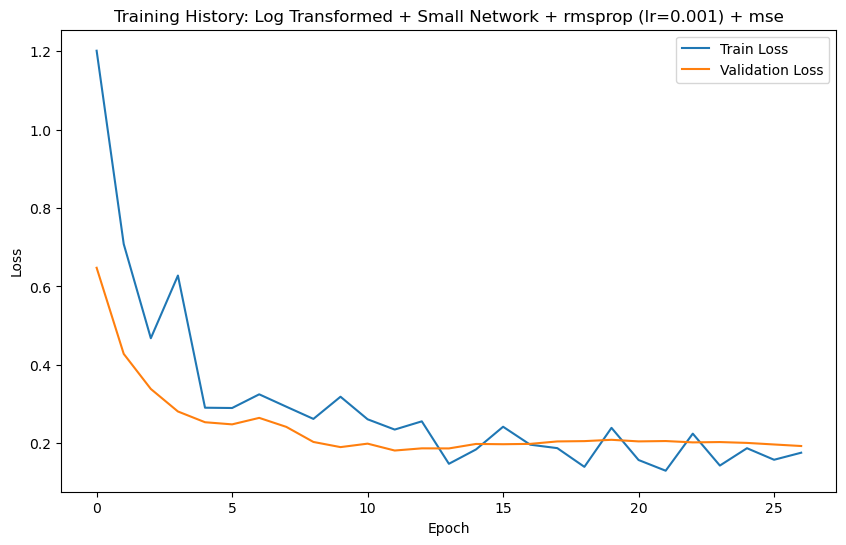



Training: Log Transformed + Small Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 767ms/step - loss: 1.0895 - root_mean_squared_error: 2.0367
Epoch 1: New best val_loss = 0.396162
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.9917 - root_mean_squared_error: 1.8085 - val_loss: 0.3962 - val_root_mean_squared_error: 0.9265 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4933 - root_mean_squared_error: 1.1838
Epoch 2: New best val_loss = 0.255958
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5489 - root_mean_squared_error: 1.1879 - val_loss: 0.2560 - val_root_mean_squared_error: 0.7338 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4237 - root_mean_squared_error: 0.9738
Epoch 3: New best val_loss = 0.175368
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3829 - root_mean_squared_error: 0.9247 - val_loss: 0.1754 - val_root_mean_squared_error: 0.6023 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3780 - root_mean_squared_error: 1.03

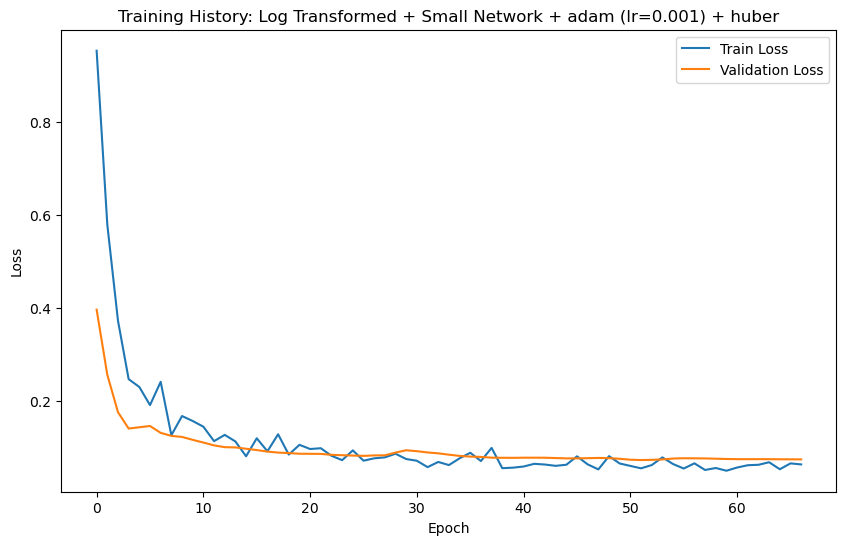



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 2.4298 - root_mean_squared_error: 1.5516
Epoch 1: New best val_loss = 1.225038
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 2.1254 - root_mean_squared_error: 1.4487 - val_loss: 1.2250 - val_root_mean_squared_error: 1.0966 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1994 - root_mean_squared_error: 1.4754
Epoch 2: New best val_loss = 0.952135
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7528 - root_mean_squared_error: 1.3129 - val_loss: 0.9521 - val_root_mean_squared_error: 0.9642 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.4384 - root_mean_squared_error: 1.1899
Epoch 3: New best val_loss = 0.729514
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4278 - root_mean_squared_error: 1.1843 - val_loss: 0.7295 - val_root_mean_squared_error: 0.8408 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.5958 - root_mean_squared_error: 1.2543


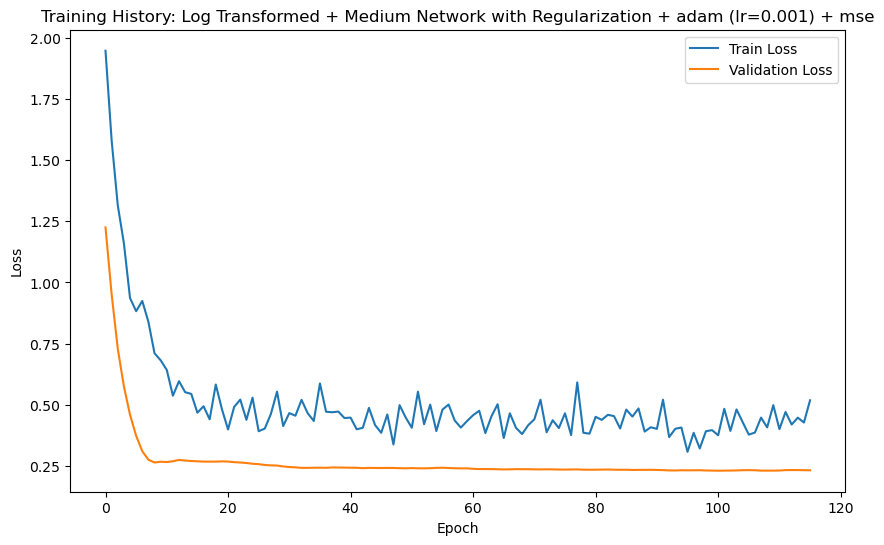



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 1.6874 - root_mean_squared_error: 1.2904
Epoch 1: New best val_loss = 0.640231
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 1.6005 - root_mean_squared_error: 1.2561 - val_loss: 0.6402 - val_root_mean_squared_error: 0.7861 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5522 - root_mean_squared_error: 1.2369
Epoch 2: New best val_loss = 0.600675
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5496 - root_mean_squared_error: 1.2358 - val_loss: 0.6007 - val_root_mean_squared_error: 0.7605 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.9496 - root_mean_squared_error: 1.3883
Epoch 3: New best val_loss = 0.568095
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6623 - root_mean_squared_error: 1.2791 - val_loss: 0.5681 - val_root_mean_squared_error: 0.7388 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4859 - root_mean_squared_e

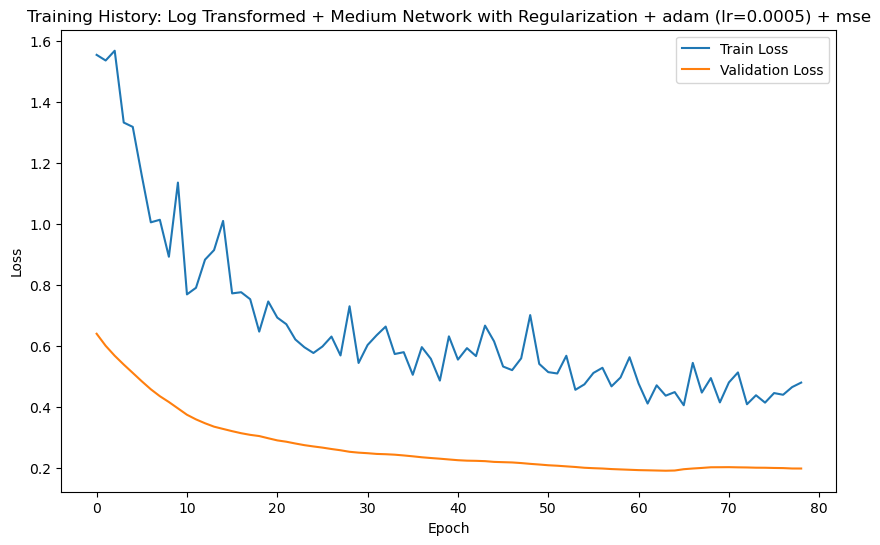



Training: Log Transformed + Medium Network with Regularization + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 2.4750 - root_mean_squared_error: 1.5660
Epoch 1: New best val_loss = 0.520858
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.6592 - root_mean_squared_error: 1.2708 - val_loss: 0.5209 - val_root_mean_squared_error: 0.7058 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.5123 - root_mean_squared_error: 1.2205
Epoch 2: New best val_loss = 0.411888
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2866 - root_mean_squared_error: 1.1217 - val_loss: 0.4119 - val_root_mean_squared_error: 0.6239 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0630 - root_mean_squared_error: 1.0200
Epoch 3: New best val_loss = 0.357041
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9964 - root_mean_squared_error: 0.9864 - val_loss: 0.3570 - val_root_mean_squared_error: 0.5782 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5099 - root_mean_squared_error: 1.2195


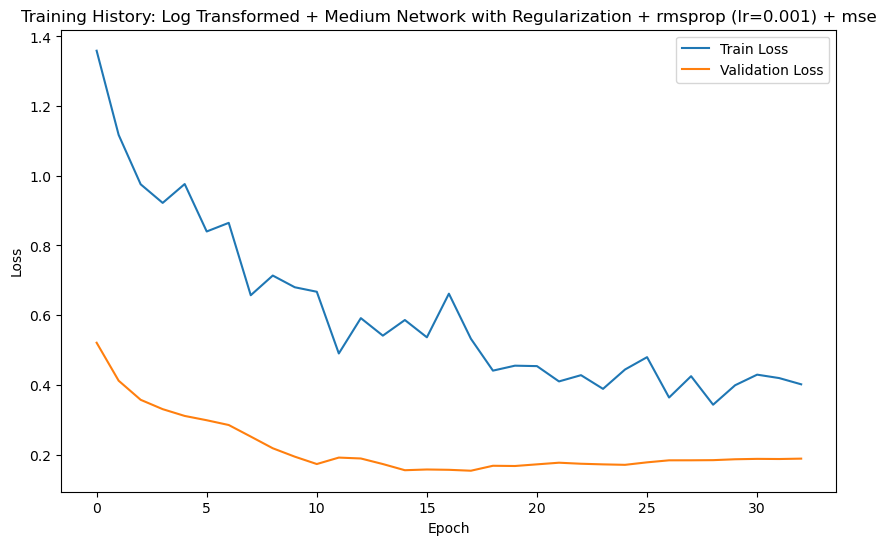



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.5082 - root_mean_squared_error: 1.0895
Epoch 1: New best val_loss = 0.301654
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.7485 - root_mean_squared_error: 1.4949 - val_loss: 0.3017 - val_root_mean_squared_error: 0.7776 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8255 - root_mean_squared_error: 1.7908
Epoch 2: New best val_loss = 0.247077
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7182 - root_mean_squared_error: 1.5697 - val_loss: 0.2471 - val_root_mean_squared_error: 0.6828 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4724 - root_mean_squared_error: 1.0137
Epoch 3: New best val_loss = 0.215053
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5516 - root_mean_squared_error: 1.1941 - val_loss: 0.2151 - val_root_mean_squared_error: 0.6266 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4542 - root_mean_squared_error: 1.0946


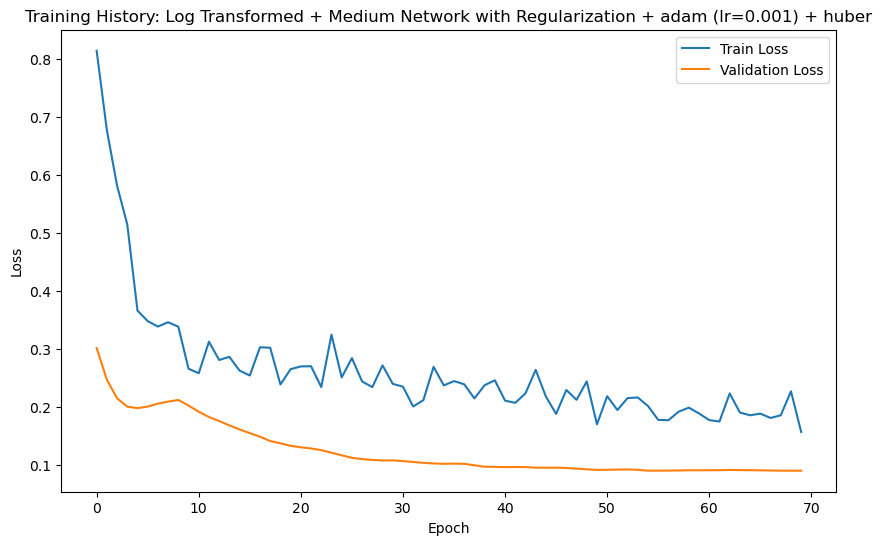



Training: Log Transformed + Deep Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 3.1389 - root_mean_squared_error: 1.7546
Epoch 1: New best val_loss = 0.654109
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 2.4269 - root_mean_squared_error: 1.5327 - val_loss: 0.6541 - val_root_mean_squared_error: 0.7705 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6444 - root_mean_squared_error: 0.7641
Epoch 2: New best val_loss = 0.568458
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0917 - root_mean_squared_error: 1.0079 - val_loss: 0.5685 - val_root_mean_squared_error: 0.7127 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8976 - root_mean_squared_error: 0.9149
Epoch 3: New best val_loss = 0.510073
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0587 - root_mean_squared_error: 0.9975 - val_loss: 0.5101 - val_root_mean_squared_error: 0.6705 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2166 - root_mean_squared_error: 1.0752


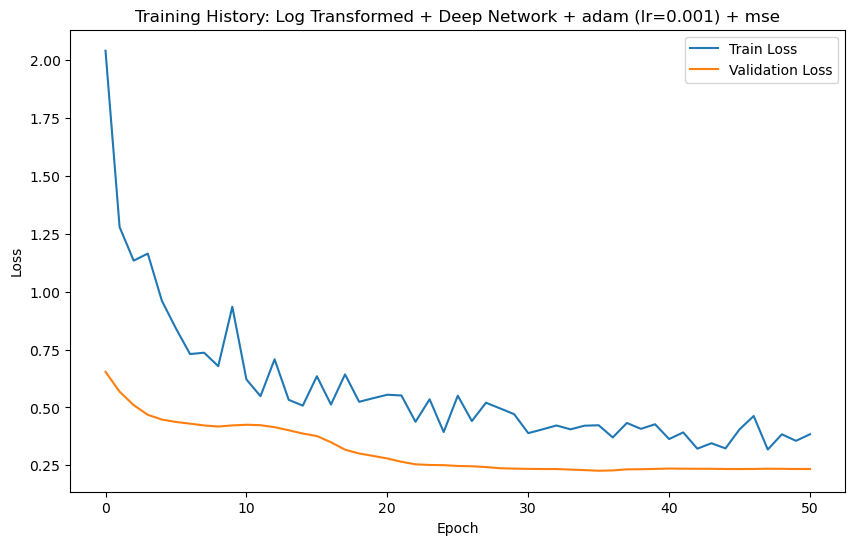



Training: Log Transformed + Deep Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 3.2270 - root_mean_squared_error: 1.7796
Epoch 1: New best val_loss = 0.814497
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 3.0503 - root_mean_squared_error: 1.7289 - val_loss: 0.8145 - val_root_mean_squared_error: 0.8685 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.1603 - root_mean_squared_error: 1.4492
Epoch 2: New best val_loss = 0.742103
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.9437 - root_mean_squared_error: 1.3717 - val_loss: 0.7421 - val_root_mean_squared_error: 0.8258 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.6609 - root_mean_squared_error: 1.2652
Epoch 3: New best val_loss = 0.680383
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.3945 - root_mean_squared_error: 1.1533 - val_loss: 0.6804 - val_root_mean_squared_error: 0.7876 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0633 - root_mean_squared_e

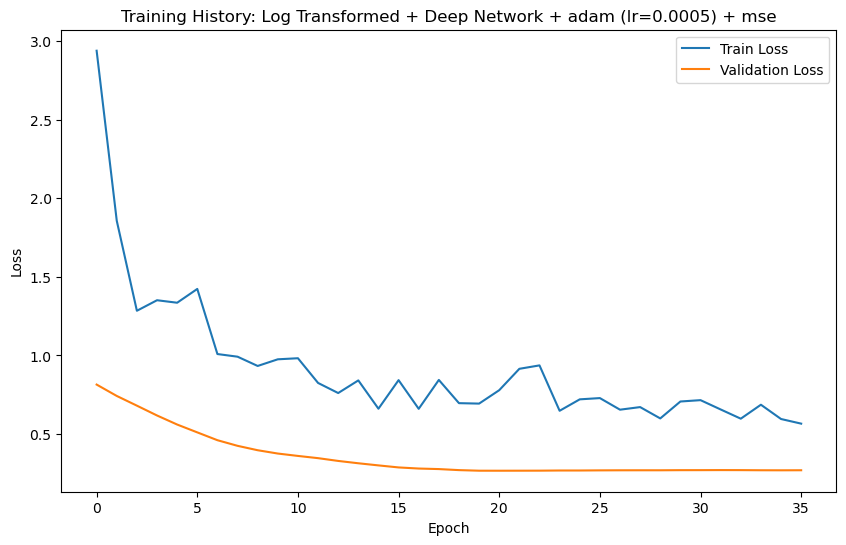



Training: Log Transformed + Deep Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.3088 - root_mean_squared_error: 1.4997
Epoch 1: New best val_loss = 0.556430
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 1.7520 - root_mean_squared_error: 1.2952 - val_loss: 0.5564 - val_root_mean_squared_error: 0.7047 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1553 - root_mean_squared_error: 1.0467
Epoch 2: New best val_loss = 0.505891
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1238 - root_mean_squared_error: 1.0314 - val_loss: 0.5059 - val_root_mean_squared_error: 0.6679 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0313 - root_mean_squared_error: 0.9857
Epoch 3: New best val_loss = 0.492778
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9822 - root_mean_squared_error: 0.9601 - val_loss: 0.4928 - val_root_mean_squared_error: 0.6580 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7371 - root_mean_squared_error: 0.8230


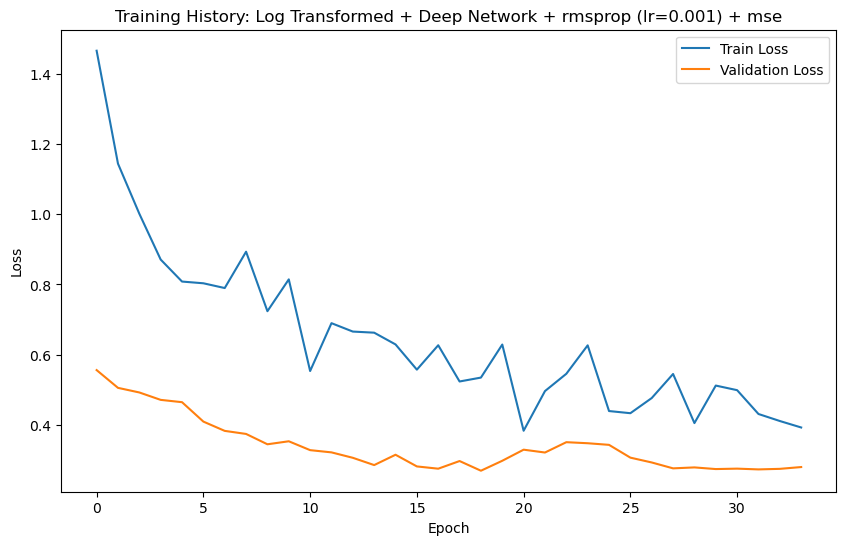



Training: Log Transformed + Deep Network + adam (lr=0.001) + huber


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 1.5209 - root_mean_squared_error: 2.1849
Epoch 1: New best val_loss = 0.659806
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.3543 - root_mean_squared_error: 2.0639 - val_loss: 0.6598 - val_root_mean_squared_error: 1.1732 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.3187 - root_mean_squared_error: 2.0673
Epoch 2: New best val_loss = 0.588994
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1589 - root_mean_squared_error: 1.8639 - val_loss: 0.5890 - val_root_mean_squared_error: 1.0841 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0254 - root_mean_squared_error: 1.5831
Epoch 3: New best val_loss = 0.519494
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9407 - root_mean_squared_error: 1.5488 - val_loss: 0.5195 - val_root_mean_squared_error: 0.9965 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8974 - root_mean_squared_er

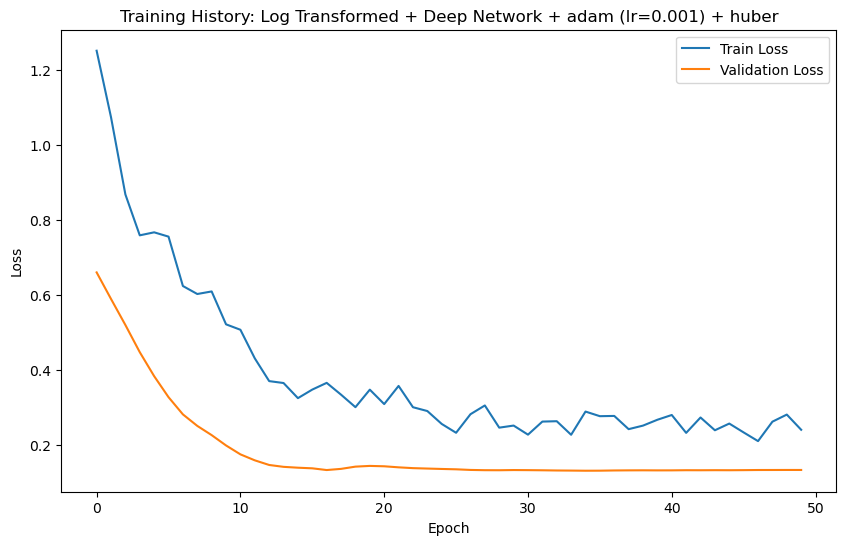



Training: Log Transformed + Wide Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.3482 - root_mean_squared_error: 1.4894
Epoch 1: New best val_loss = 0.668358
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 1.7416 - root_mean_squared_error: 1.2641 - val_loss: 0.6684 - val_root_mean_squared_error: 0.7337 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5055 - root_mean_squared_error: 1.1728
Epoch 2: New best val_loss = 0.477887
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4575 - root_mean_squared_error: 1.1521 - val_loss: 0.4779 - val_root_mean_squared_error: 0.5896 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.2518 - root_mean_squared_error: 1.0590
Epoch 3: New best val_loss = 0.423495
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2176 - root_mean_squared_error: 1.0425 - val_loss: 0.4235 - val_root_mean_squared_error: 0.5414 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2175 - root_mean_squared_error: 1.0426


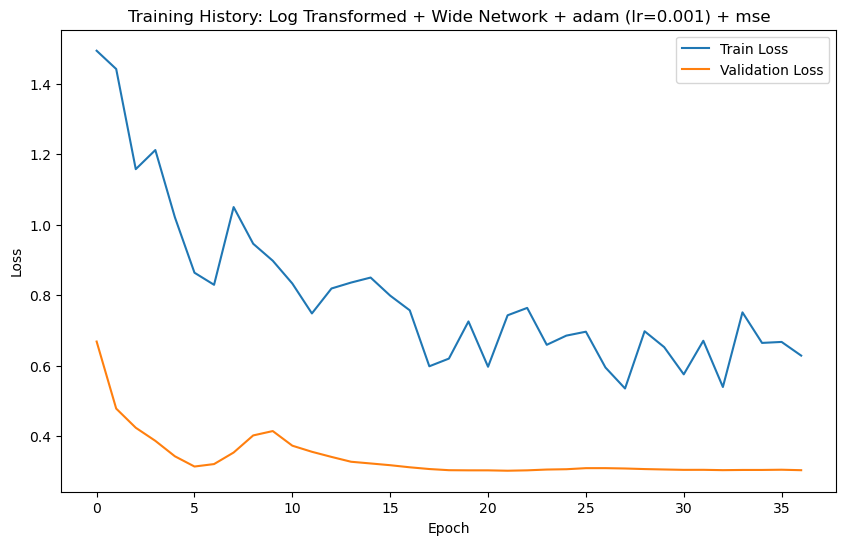



Training: Log Transformed + Wide Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 3.3968 - root_mean_squared_error: 1.8076
Epoch 1: New best val_loss = 0.754824
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 2.9818 - root_mean_squared_error: 1.6874 - val_loss: 0.7548 - val_root_mean_squared_error: 0.7908 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.2861 - root_mean_squared_error: 1.4686
Epoch 2: New best val_loss = 0.614018
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.9467 - root_mean_squared_error: 1.3461 - val_loss: 0.6140 - val_root_mean_squared_error: 0.6961 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.6077 - root_mean_squared_error: 1.2159
Epoch 3: New best val_loss = 0.527167
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6099 - root_mean_squared_error: 1.2167 - val_loss: 0.5272 - val_root_mean_squared_error: 0.6306 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.5374 - root_mean_squared_e

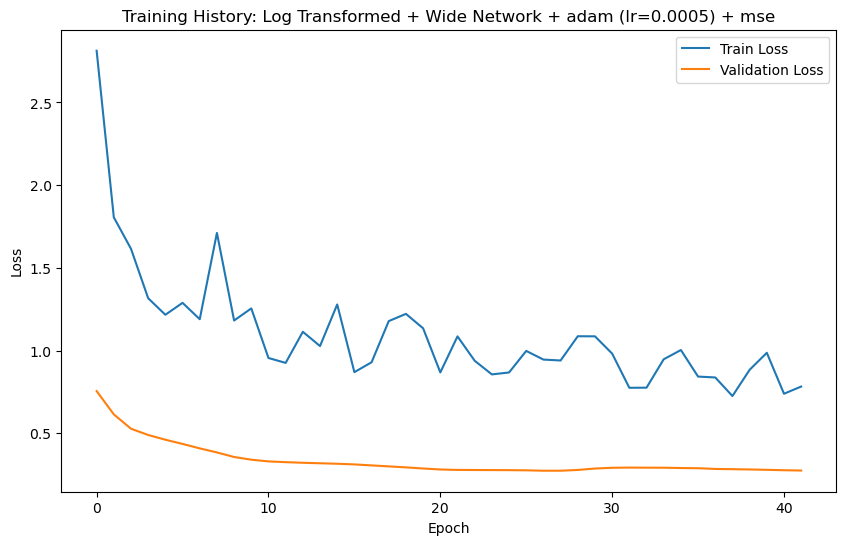



Training: Log Transformed + Wide Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3.0204 - root_mean_squared_error: 1.7002
Epoch 1: New best val_loss = 0.639590
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 1.9931 - root_mean_squared_error: 1.3556 - val_loss: 0.6396 - val_root_mean_squared_error: 0.7137 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.6672 - root_mean_squared_error: 1.2397
Epoch 2: New best val_loss = 0.577202
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3561 - root_mean_squared_error: 1.1055 - val_loss: 0.5772 - val_root_mean_squared_error: 0.6684 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9046 - root_mean_squared_error: 0.8799
Epoch 3: New best val_loss = 0.406161
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9882 - root_mean_squared_error: 0.9254 - val_loss: 0.4062 - val_root_mean_squared_error: 0.5250 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9224 - root_mean_squared_error: 0.8897 

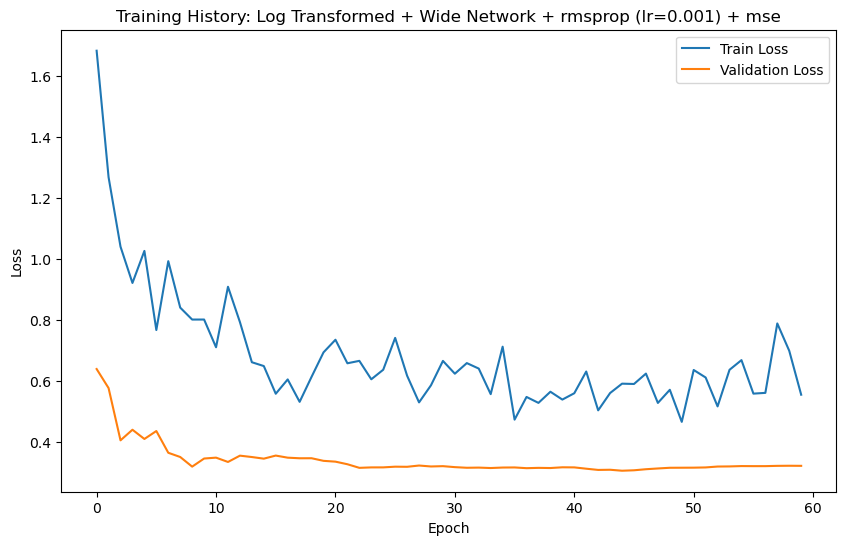



Training: Log Transformed + Wide Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 1.1024 - root_mean_squared_error: 1.7650
Epoch 1: New best val_loss = 0.446947
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.8426 - root_mean_squared_error: 1.4552 - val_loss: 0.4469 - val_root_mean_squared_error: 0.8138 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6886 - root_mean_squared_error: 1.2740
Epoch 2: New best val_loss = 0.367525
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6733 - root_mean_squared_error: 1.2298 - val_loss: 0.3675 - val_root_mean_squared_error: 0.6953 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5535 - root_mean_squared_error: 1.0512
Epoch 3: New best val_loss = 0.311259
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5625 - root_mean_squared_error: 1.0273 - val_loss: 0.3113 - val_root_mean_squared_error: 0.6025 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4586 - root_mean_squared_error: 0.8867


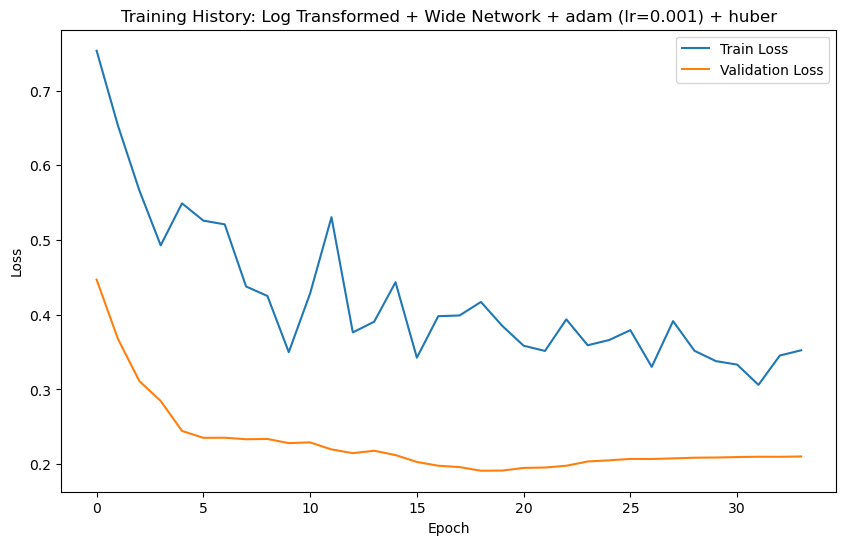



Training: Log Transformed + PReLU Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 2.3063 - root_mean_squared_error: 1.5010
Epoch 1: New best val_loss = 0.842331
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 1.6891 - root_mean_squared_error: 1.2727 - val_loss: 0.8423 - val_root_mean_squared_error: 0.8883 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4489 - root_mean_squared_error: 1.1814
Epoch 2: New best val_loss = 0.717454
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1696 - root_mean_squared_error: 1.0547 - val_loss: 0.7175 - val_root_mean_squared_error: 0.8150 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3644 - root_mean_squared_error: 1.1450
Epoch 3: New best val_loss = 0.603899
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1133 - root_mean_squared_error: 1.0280 - val_loss: 0.6039 - val_root_mean_squared_error: 0.7420 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0076 - root_mean_squared_error: 0.9769


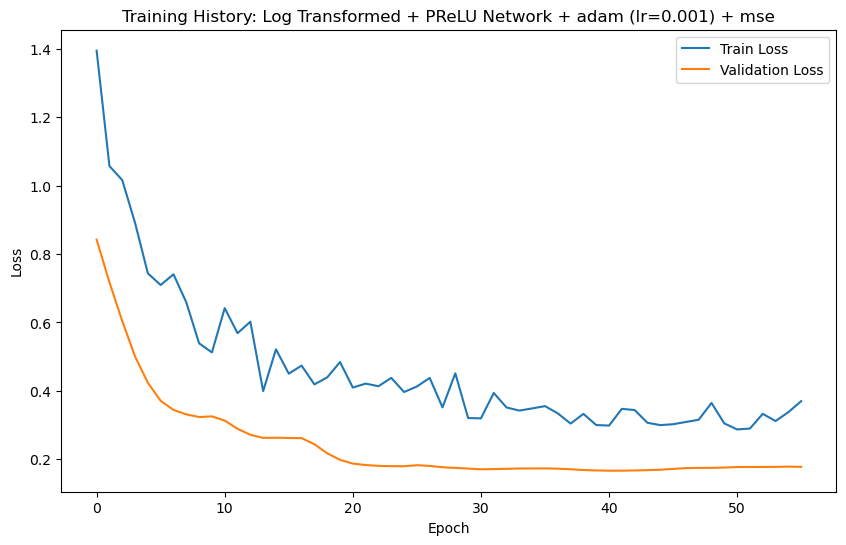



Training: Log Transformed + PReLU Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 1.7284 - root_mean_squared_error: 1.2942
Epoch 1: New best val_loss = 0.937141
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 1.6612 - root_mean_squared_error: 1.2679 - val_loss: 0.9371 - val_root_mean_squared_error: 0.9400 - learning_rate: 5.0000e-04
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.3244 - root_mean_squared_error: 1.1271 - val_loss: 0.9388 - val_root_mean_squared_error: 0.9409 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2329 - root_mean_squared_error: 1.0860
Epoch 3: New best val_loss = 0.918806
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.1648 - root_mean_squared_error: 1.0540 - val_loss: 0.9188 - val_root_mean_squared_error: 0.9302 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0726 - root_mean_squared_error: 1.0095
Epoch 4: New best val_loss = 0.892475
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1296 - root_mean_squared_e

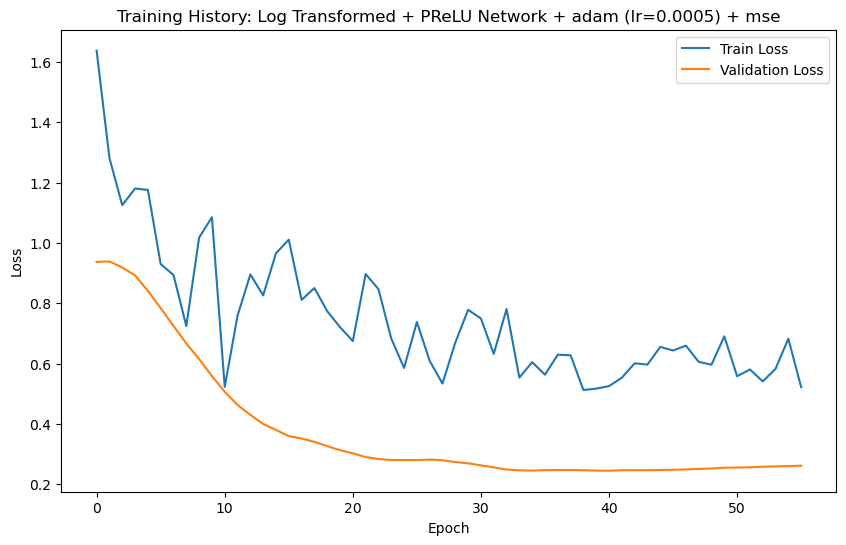



Training: Log Transformed + PReLU Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 2.2445 - root_mean_squared_error: 1.4803
Epoch 1: New best val_loss = 0.458037
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 1.5919 - root_mean_squared_error: 1.2354 - val_loss: 0.4580 - val_root_mean_squared_error: 0.6361 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7012 - root_mean_squared_error: 0.8048
Epoch 2: New best val_loss = 0.421828
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8822 - root_mean_squared_error: 0.9090 - val_loss: 0.4218 - val_root_mean_squared_error: 0.6069 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6473 - root_mean_squared_error: 0.7706
Epoch 3: New best val_loss = 0.372122
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7123 - root_mean_squared_error: 0.8114 - val_loss: 0.3721 - val_root_mean_squared_error: 0.5645 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5683 - root_mean_squared_error: 0.7175


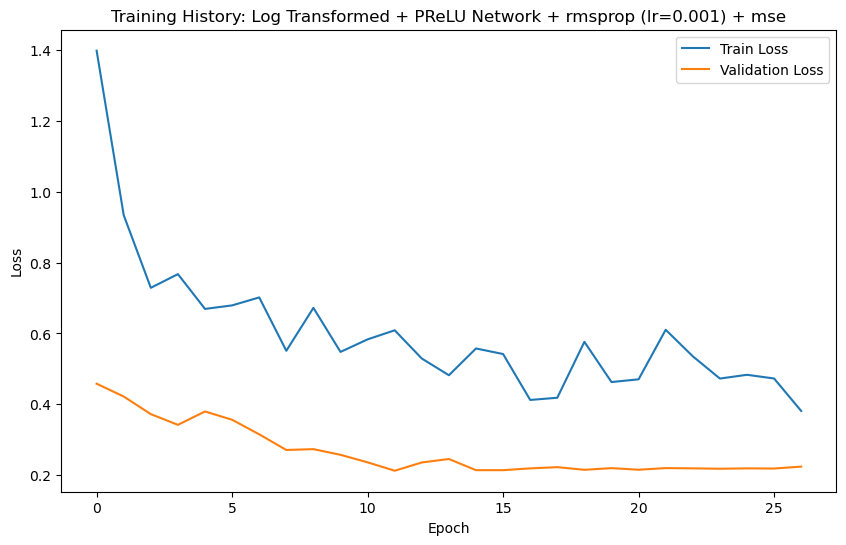



Training: Log Transformed + PReLU Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.7984 - root_mean_squared_error: 1.4899
Epoch 1: New best val_loss = 0.311294
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.7182 - root_mean_squared_error: 1.3534 - val_loss: 0.3113 - val_root_mean_squared_error: 0.7253 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4619 - root_mean_squared_error: 0.9508
Epoch 2: New best val_loss = 0.311258
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4755 - root_mean_squared_error: 1.0324 - val_loss: 0.3113 - val_root_mean_squared_error: 0.7212 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3035 - root_mean_squared_error: 0.7135
Epoch 3: New best val_loss = 0.297930
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3708 - root_mean_squared_error: 0.8353 - val_loss: 0.2979 - val_root_mean_squared_error: 0.7014 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3219 - root_mean_squared_error: 0.7907


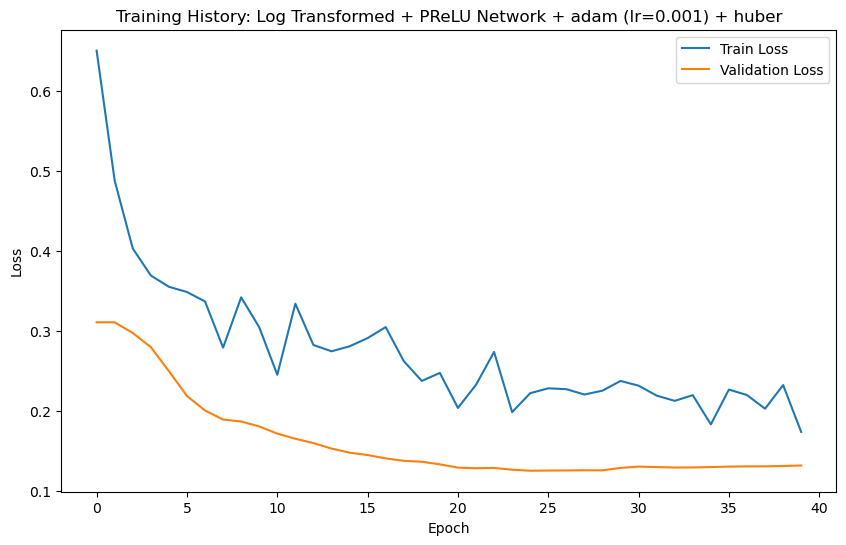

In [7]:
# Store results
search_results = []

# Systematic search through combinations
for target in target_options:
    for arch in architecture_search_space:
        for params in training_params:
            # Create a unique name for this configuration
            config_name = f"{target['name']} + {arch['name']} + {params['optimizer']} (lr={params['learning_rate']}) + {params['loss']}"
            print(f"\n\nTraining: {config_name}")
            
            # Create model
            model = create_model_architecture(X_train_main.shape[1], arch)
            
            # Train model
            trained_model, history, training_time = train_model(
                target['X_train'], target['y_train'],
                target['X_val'], target['y_val'],
                model=model,
                batch_size=params['batch_size'],
                optimizer=params['optimizer'],
                learning_rate=params['learning_rate'],
                loss=params['loss'],
                patience=15
            )
            
            # Evaluate on test set
            y_pred = trained_model.predict(target['X_test'])
            
            # Convert to original scale
            y_pred_original = target['inverse_func'](y_pred)
            y_test_original = target['inverse_func'](target['y_test'])
            
            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
            mae = mean_absolute_error(y_test_original, y_pred_original)
            r2 = r2_score(y_test_original, y_pred_original)
            
            print(f"Results for {config_name}:")
            print(f"RMSE: {rmse:.2f}")
            print(f"MAE: {mae:.2f}")
            print(f"R² Score: {r2:.4f}")
            print(f"Training time: {training_time:.2f} seconds")
            
            # Plot learning curves
            plt.figure(figsize=(10, 6))
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title(f'Training History: {config_name}')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend()
            plt.show()
            
            # Store results
            search_results.append({
                'name': config_name,
                'architecture': arch['name'],
                'target_transformation': target['name'],
                'optimizer': params['optimizer'],
                'learning_rate': params['learning_rate'],
                'loss': params['loss'],
                'batch_size': params['batch_size'],
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'training_time': training_time,
                'model': trained_model,
                'history': history,
                'y_pred': y_pred_original,
                'y_test': y_test_original
            })

## 8. Analyze Architecture Search Results

,Config,Architecture,Target,Optimizer,Learning Rate,Loss,RMSE,MAE,R²,Time (s)
6,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,Standard Scaled,rmsprop,0.0010,mse,3835.118379,2195.063664,0.820559,5.030049
18,Standard Scaled + PReLU Network + rmsprop (lr=...,PReLU Network,Standard Scaled,rmsprop,0.0010,mse,3837.604616,2244.104868,0.820327,4.708141
16,Standard Scaled + PReLU Network + adam (lr=0.0...,PReLU Network,Standard Scaled,adam,0.0010,mse,3846.867951,2165.638359,0.819458,8.997687
10,Standard Scaled + Deep Network + rmsprop (lr=0...,Deep Network,Standard Scaled,rmsprop,0.0010,mse,3876.285791,2300.330529,0.816686,5.289137
4,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,Standard Scaled,adam,0.0010,mse,3878.853504,2037.044534,0.816443,7.240166
9,Standard Scaled + Deep Network + adam (lr=0.00...,Deep Network,Standard Scaled,adam,0.0005,mse,3881.827212,2300.878981,0.816162,6.803987
12,Standard Scaled + Wide Network + adam (lr=0.00...,Wide Network,Standard Scaled,adam,0.0010,mse,3927.607363,2310.476149,0.811800,5.265754
28,Log Transformed + Deep Network + adam (lr=0.00...,Deep Network,Log Transformed,adam,0.0010,mse,4075.739846,2158.434182,0.797336,5.885653
19,Standard Scaled + PReLU Network + adam (lr=0.0...,PReLU Network,Standard Scaled,adam,0.0010,huber,4161.559271,2227.633551,0.788712,7.683200
11,Standard Scaled + Deep Network + adam (lr=0.00...,Deep Network,Standard Scaled,adam,0.0010,huber,4162.667809,2218.474159,0.788599,9.177656



Best Model: Standard Scaled + Medium Network with Regularization + rmsprop (lr=0.001) + mse
RMSE: 3835.12
MAE: 2195.06
R² Score: 0.8206


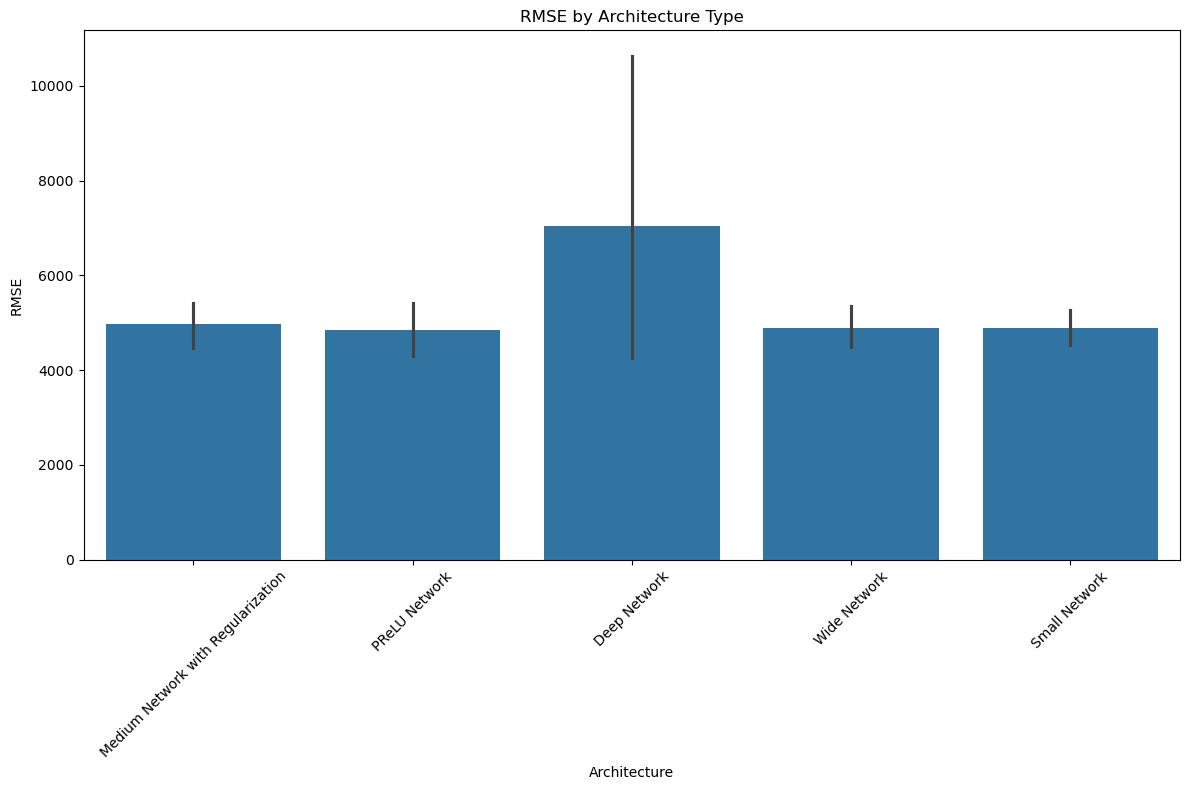

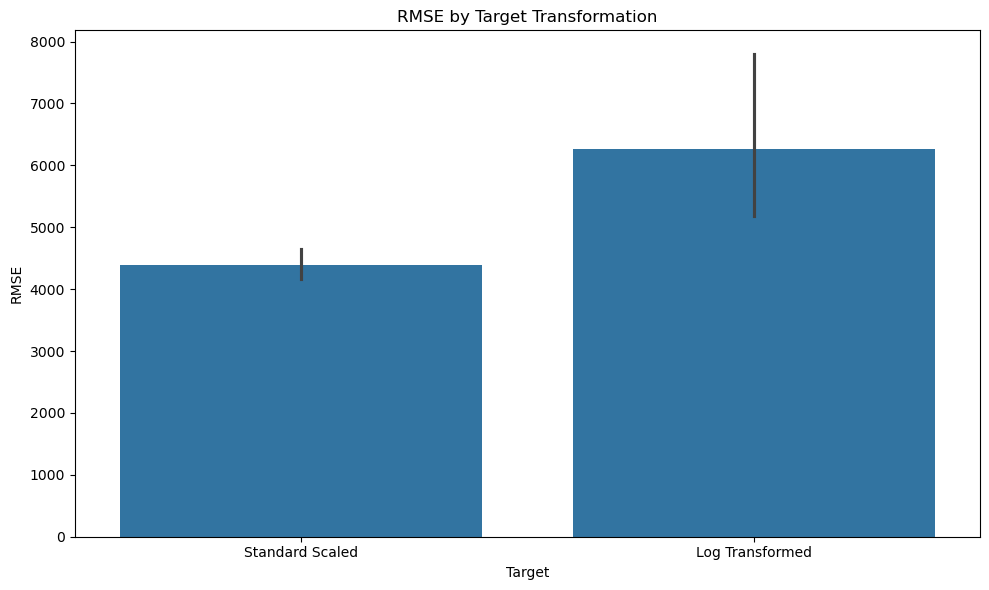

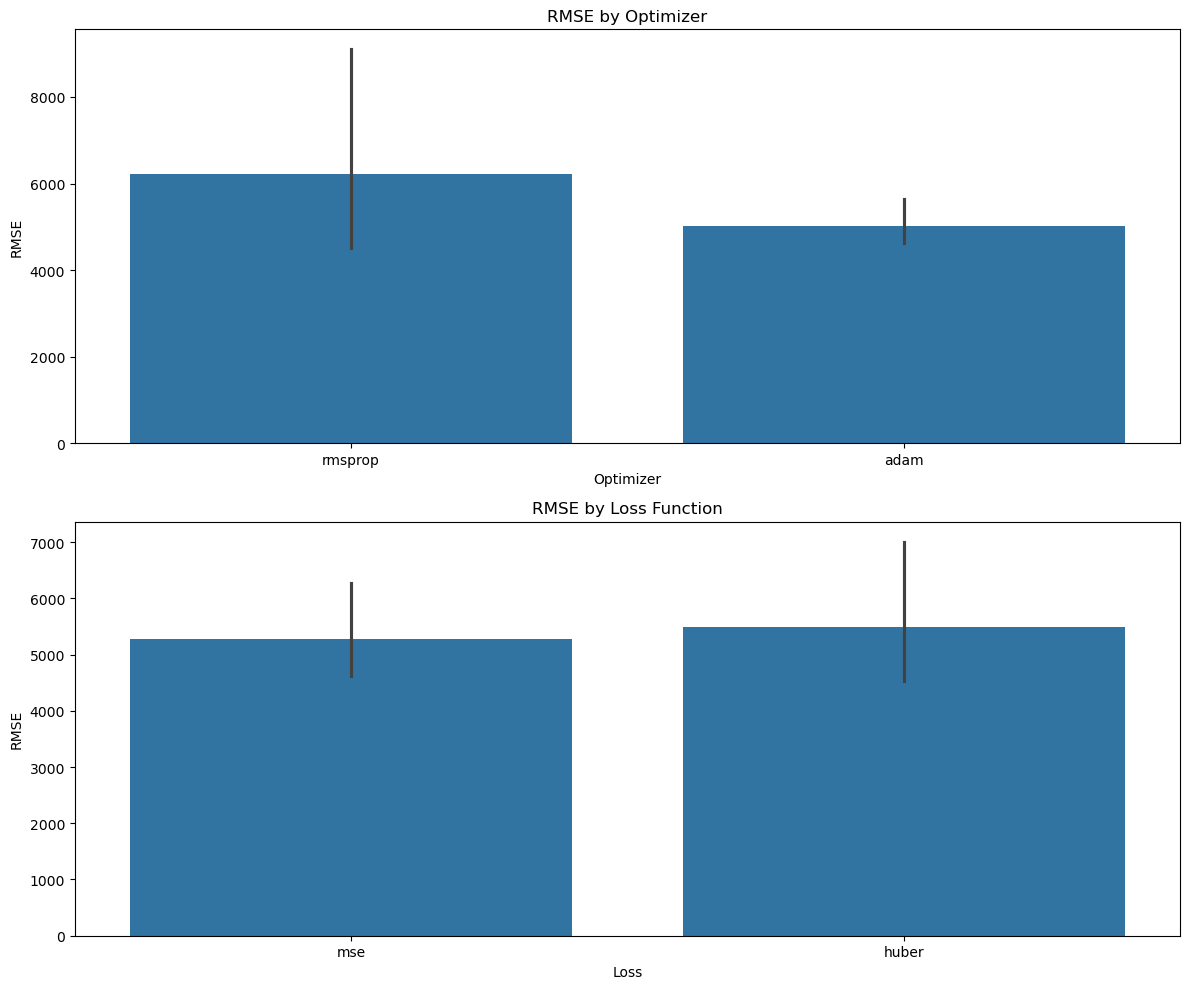

In [8]:
# Create a DataFrame with the results
results_df = pd.DataFrame([
    {'Config': r['name'], 'Architecture': r['architecture'], 'Target': r['target_transformation'],
     'Optimizer': r['optimizer'], 'Learning Rate': r['learning_rate'], 'Loss': r['loss'],
     'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2'], 'Time (s)': r['training_time']}
    for r in search_results
])

# Sort by RMSE (primary metric)
results_df_sorted = results_df.sort_values('RMSE')
display(results_df_sorted)

# Find best model
best_model_config = search_results[results_df_sorted.index[0]]
print(f"\nBest Model: {best_model_config['name']}")
print(f"RMSE: {best_model_config['rmse']:.2f}")
print(f"MAE: {best_model_config['mae']:.2f}")
print(f"R² Score: {best_model_config['r2']:.4f}")

# Plot comparisons of different architectures
plt.figure(figsize=(12, 8))
sns.barplot(x='Architecture', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Architecture Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot comparisons of target transformations
plt.figure(figsize=(10, 6))
sns.barplot(x='Target', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Target Transformation')
plt.tight_layout()
plt.show()

# Plot comparisons of optimizers and loss functions
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
sns.barplot(x='Optimizer', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Optimizer')

plt.subplot(2, 1, 2)
sns.barplot(x='Loss', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Loss Function')
plt.tight_layout()
plt.show()

## 9. Fine-tuning the Best Model

In [9]:
# Extract information about the best model configuration
best_architecture = next(a for a in architecture_search_space if a['name'] == best_model_config['architecture'])
best_target = next(t for t in target_options if t['name'] == best_model_config['target_transformation'])

# Fine-tune by making small adjustments to the best architecture
fine_tuned_architectures = [
    # Slight variations of the best architecture
    {
        'name': f"Fine-Tuned {best_architecture['name']} v1",
        'layer_sizes': best_architecture['layer_sizes'].copy(),  # Add 20% more neurons
        'dropout_rates': [rate * 0.9 for rate in best_architecture['dropout_rates']],  # Slightly less dropout
        'activation': best_architecture['activation'],
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    },
    {
        'name': f"Fine-Tuned {best_architecture['name']} v2",
        'layer_sizes': best_architecture['layer_sizes'] + [16],  # Add one more layer
        'dropout_rates': best_architecture['dropout_rates'] + [0.1],  # Add dropout for the new layer
        'activation': best_architecture['activation'],
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    },
    {
        'name': f"Fine-Tuned {best_architecture['name']} v3",
        'layer_sizes': best_architecture['layer_sizes'],
        'dropout_rates': best_architecture['dropout_rates'],
        'activation': 'prelu' if best_architecture['activation'] != 'prelu' else 'leaky_relu',  # Try different activation
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    }
]

# Fine-tune training parameters
fine_tuned_params = [
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'] * 0.5,  # Lower learning rate
        'batch_size': best_model_config['batch_size'],
        'loss': best_model_config['loss']
    },
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'],
        'batch_size': best_model_config['batch_size'] * 2,  # Larger batch size
        'loss': best_model_config['loss']
    },
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'],
        'batch_size': best_model_config['batch_size'],
        'loss': 'huber' if best_model_config['loss'] != 'huber' else 'mse'  # Try different loss
    }
]

# Run fine-tuning
fine_tuning_results = []

# Include the original best model for comparison
fine_tuning_results.append(best_model_config)

# Train fine-tuned models
for arch in fine_tuned_architectures:
    for params in fine_tuned_params:
        # Create a unique name for this configuration
        config_name = f"{best_target['name']} + {arch['name']} + {params['optimizer']} (lr={params['learning_rate']}) + {params['loss']}"
        print(f"\n\nFine-Tuning: {config_name}")
        
        # Create model
        model = create_model_architecture(best_target['X_train'].shape[1], arch)
        
        # Train with longer patience for fine-tuning
        trained_model, history, training_time = train_model(
            best_target['X_train'], best_target['y_train'],
            best_target['X_val'], best_target['y_val'],
            model=model,
            batch_size=params['batch_size'],
            optimizer=params['optimizer'],
            learning_rate=params['learning_rate'],
            loss=params['loss'],
            patience=20  # Longer patience for fine-tuning
        )
        
        # Evaluate on test set
        y_pred = trained_model.predict(best_target['X_test'])
        
        # Convert to original scale
        y_pred_original = best_target['inverse_func'](y_pred)
        y_test_original = best_target['inverse_func'](best_target['y_test'])
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        mae = mean_absolute_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)
        
        print(f"Results for fine-tuned model:")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")
        print(f"R² Score: {r2:.4f}")
        
        # Store results
        fine_tuning_results.append({
            'name': config_name,
            'architecture': arch['name'],
            'target_transformation': best_target['name'],
            'optimizer': params['optimizer'],
            'learning_rate': params['learning_rate'],
            'loss': params['loss'],
            'batch_size': params['batch_size'],
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'training_time': training_time,
            'model': trained_model,
            'history': history,
            'y_pred': y_pred_original,
            'y_test': y_test_original
        })



Fine-Tuning: Standard Scaled + Fine-Tuned Medium Network with Regularization v1 + rmsprop (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.5785 - root_mean_squared_error: 1.5987
Epoch 1: New best val_loss = 1.794839
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 2.5863 - root_mean_squared_error: 1.6009 - val_loss: 1.7948 - val_root_mean_squared_error: 1.3312 - learning_rate: 5.0000e-04
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.3371 - root_mean_squared_error: 1.5213
Epoch 2: New best val_loss = 1.618934
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3577 - root_mean_squared_error: 1.5263 - val_loss: 1.6189 - val_root_mean_squared_error: 1.2634 - learning_rate: 5.0000e-04
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.9194 - root_mean_squared_error: 1.7020
Epoch 3: New best val_loss = 1.411856
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5291 - root_mean_squared_error: 1.5818 - val_loss: 1.4119 - val_root_mean_squared_error: 1.1786 - learning_rate: 5.0000e-04
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.3446 - root_mean_squared_er

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 1.7323 - root_mean_squared_error: 1.3076
Epoch 1: New best val_loss = 0.504543
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 1.7241 - root_mean_squared_error: 1.3045 - val_loss: 0.5045 - val_root_mean_squared_error: 0.6944 - learning_rate: 0.0010
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7358 - root_mean_squared_error: 0.8446
Epoch 2: New best val_loss = 0.495928
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0775 - root_mean_squared_error: 1.0220 - val_loss: 0.4959 - val_root_mean_squared_error: 0.6882 - learning_rate: 0.0010
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7685 - root_mean_squared_error: 0.8638
Epoch 3: New best val_loss = 0.486750
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8895 - root_mean_squared_error: 0.9304 - val_loss: 0.4868 - val_root_mean_squared_error: 0.6815 - learning_rate: 0.0010
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.7589 - root_mean_squared_error: 0.8577

...

Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.8743 - root_mean_squared_error: 1.3607
Epoch 1: New best val_loss = 0.568326
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 2.0132 - root_mean_squared_error: 1.4105 - val_loss: 0.5683 - val_root_mean_squared_error: 0.7387 - learning_rate: 5.0000e-04
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.7091 - root_mean_squared_error: 1.2986
Epoch 2: New best val_loss = 0.477626
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.6967 - root_mean_squared_error: 1.2936 - val_loss: 0.4776 - val_root_mean_squared_error: 0.6745 - learning_rate: 5.0000e-04
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.7158 - root_mean_squared_error: 1.3012
Epoch 3: New best val_loss = 0.430046
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.4590 - root_mean_squared_error: 1.1975 - val_loss: 0.4300 - val_root_mean_squared_error: 0.6382 - learning_rate: 5.0000e-04
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.3971 - root_mea

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 2.3898 - root_mean_squared_error: 1.5386
Epoch 1: New best val_loss = 0.617600
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 2.0189 - root_mean_squared_error: 1.4110 - val_loss: 0.6176 - val_root_mean_squared_error: 0.7714 - learning_rate: 0.0010
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1516 - root_mean_squared_error: 1.0625
Epoch 2: New best val_loss = 0.542029
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0392 - root_mean_squared_error: 1.0078 - val_loss: 0.5420 - val_root_mean_squared_error: 0.7207 - learning_rate: 0.0010
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8233 - root_mean_squared_error: 0.8948
Epoch 3: New best val_loss = 0.516743
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9035 - root_mean_squared_error: 0.9382 - val_loss: 0.5167 - val_root_mean_squared_error: 0.7030 - learning_rate: 0.0010
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8885 - root_mean_squared_error: 0.9305

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 1.0525 - root_mean_squared_error: 1.8088
Epoch 1: New best val_loss = 0.298724
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.7260 - root_mean_squared_error: 1.4313 - val_loss: 0.2987 - val_root_mean_squared_error: 0.7613 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7254 - root_mean_squared_error: 1.4313
Epoch 2: New best val_loss = 0.225496
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5636 - root_mean_squared_error: 1.1933 - val_loss: 0.2255 - val_root_mean_squared_error: 0.6493 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4757 - root_mean_squared_error: 1.1294
Epoch 3: New best val_loss = 0.172319
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4353 - root_mean_squared_error: 1.0410 - val_loss: 0.1723 - val_root_mean_squared_error: 0.5577 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4161 - root_mean_squared_error: 0.9855


## 10. Analyze Fine-Tuning Results

In [10]:
# Create a DataFrame with the fine-tuning results
fine_tuning_df = pd.DataFrame([
    {'Config': r['name'], 'Architecture': r['architecture'],
     'Optimizer': r['optimizer'], 'Learning Rate': r['learning_rate'], 'Loss': r['loss'],
     'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2'], 'Time (s)': r['training_time']}
    for r in fine_tuning_results
])

# Sort by RMSE
fine_tuning_df_sorted = fine_tuning_df.sort_values('RMSE')
display(fine_tuning_df_sorted)

# Find the best fine-tuned model
best_fine_tuned = fine_tuning_results[fine_tuning_df_sorted.index[0]]
print(f"\nBest Fine-Tuned Model: {best_fine_tuned['name']}")
print(f"RMSE: {best_fine_tuned['rmse']:.2f}")
print(f"MAE: {best_fine_tuned['mae']:.2f}")
print(f"R² Score: {best_fine_tuned['r2']:.4f}")

# Show improvement over initial best model
improvement_rmse = ((best_model_config['rmse'] - best_fine_tuned['rmse']) / best_model_config['rmse']) * 100
improvement_r2 = ((best_fine_tuned['r2'] - best_model_config['r2']) / best_model_config['r2']) * 100

print(f"\nImprovement over initial best model:")
print(f"RMSE improvement: {improvement_rmse:.2f}%")
print(f"R² improvement: {improvement_r2:.2f}%")

,Config,Architecture,Optimizer,Learning Rate,Loss,RMSE,MAE,R²,Time (s)
9,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v3,rmsprop,0.0010,huber,3521.162139,1998.541567,0.848736,5.747686
0,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,rmsprop,0.0010,mse,3835.118379,2195.063664,0.820559,5.030049
5,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v2,rmsprop,0.0010,mse,4145.888432,2273.981458,0.790300,6.942301
4,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v2,rmsprop,0.0005,mse,4372.132151,2682.513534,0.766789,7.378245
2,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v1,rmsprop,0.0010,mse,4374.473238,2309.462465,0.766539,7.856984
6,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v2,rmsprop,0.0010,huber,4452.407573,2233.551470,0.758146,7.590398
8,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v3,rmsprop,0.0010,mse,4474.419057,2289.466834,0.755749,9.822985
1,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v1,rmsprop,0.0005,mse,4482.688151,2527.873648,0.754845,10.135736
3,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v1,rmsprop,0.0010,huber,4740.358207,2733.127842,0.725852,7.398619
7,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v3,rmsprop,0.0005,mse,4799.036371,3041.670848,0.719023,5.437512



Best Fine-Tuned Model: Standard Scaled + Fine-Tuned Medium Network with Regularization v3 + rmsprop (lr=0.001) + huber
RMSE: 3521.16
MAE: 1998.54
R² Score: 0.8487

Improvement over initial best model:
RMSE improvement: 8.19%
R² improvement: 3.43%


## 11. Final Model Analysis and Visualization

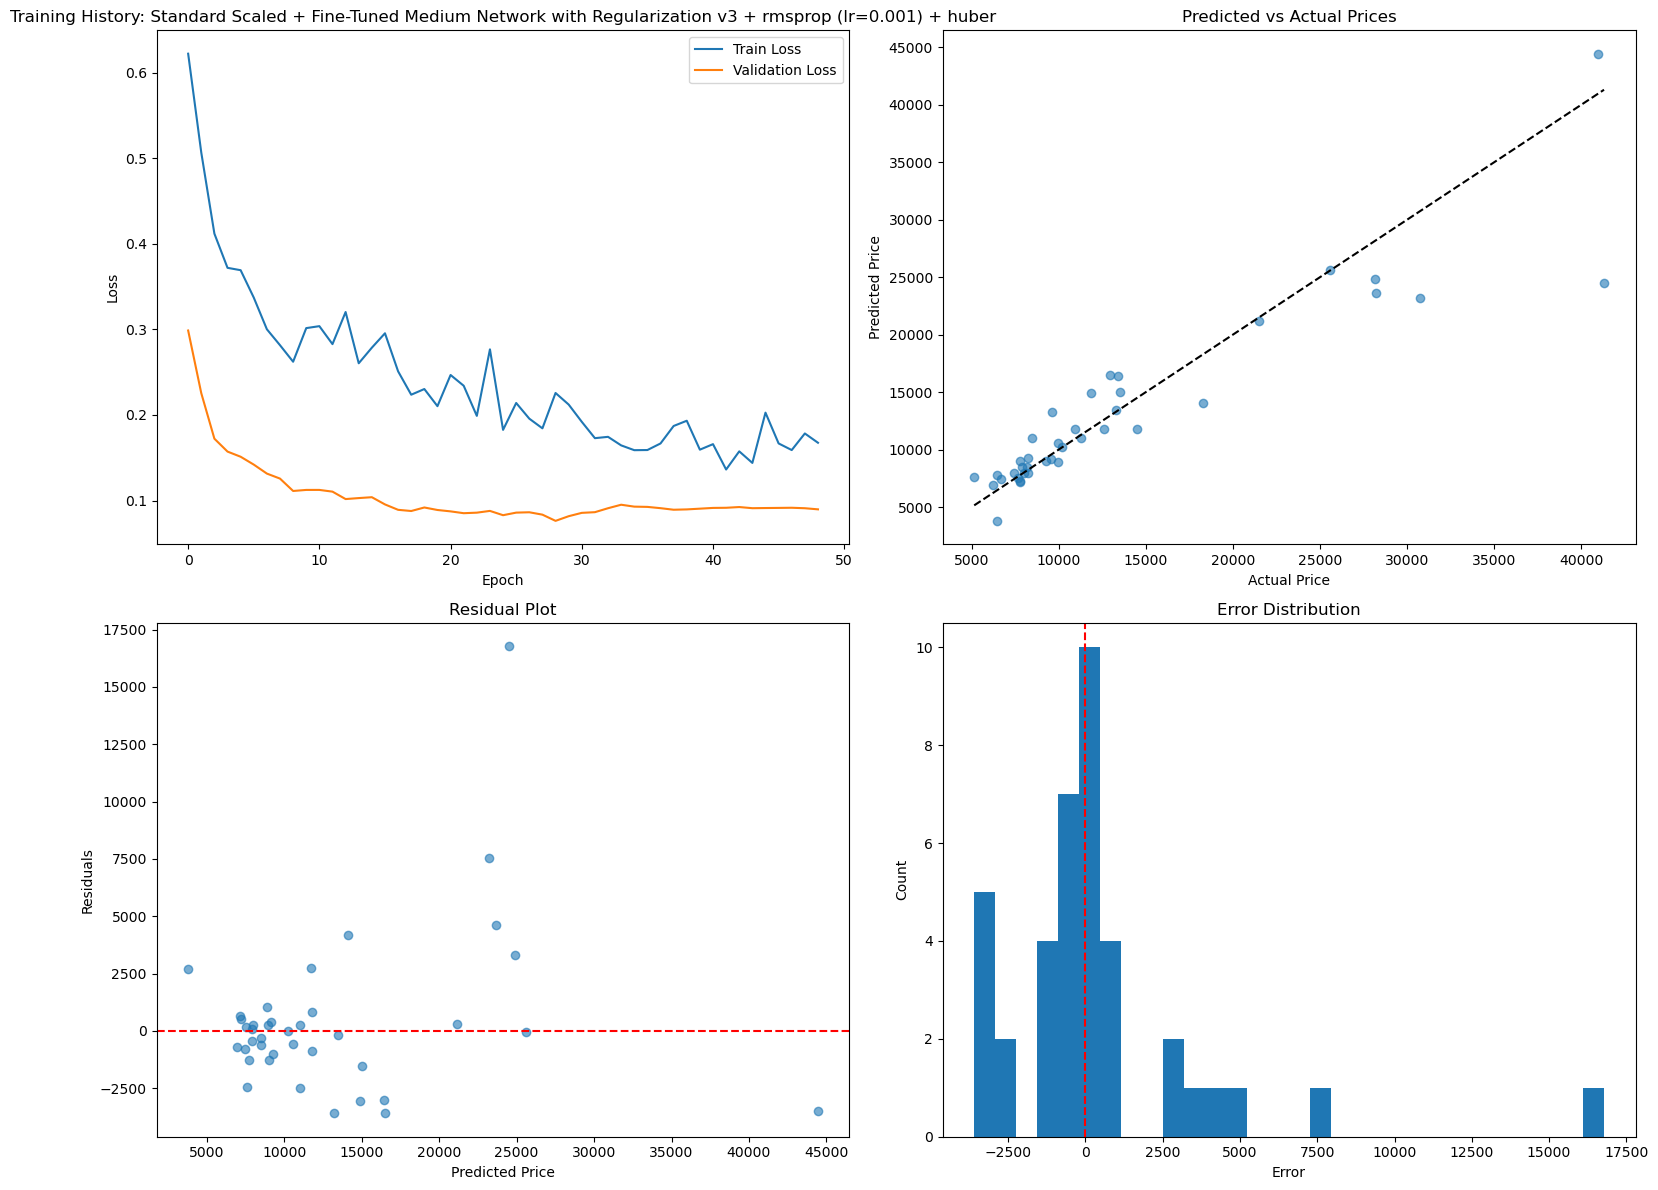

In [11]:
# Select the final best model - either from initial search or fine-tuning
final_model = best_fine_tuned if best_fine_tuned['rmse'] < best_model_config['rmse'] else best_model_config

# Visualize the final model's performance
plt.figure(figsize=(16, 12))

# Plot training & validation loss
plt.subplot(2, 2, 1)
plt.plot(final_model['history'].history['loss'], label='Train Loss')
plt.plot(final_model['history'].history['val_loss'], label='Validation Loss')
plt.title(f'Training History: {final_model["name"]}')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot predictions vs actual
plt.subplot(2, 2, 2)
plt.scatter(final_model['y_test'], final_model['y_pred'], alpha=0.6)
plt.plot([min(final_model['y_test']), max(final_model['y_test'])], 
         [min(final_model['y_test']), max(final_model['y_test'])], 'k--')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot residuals
residuals = final_model['y_test'] - final_model['y_pred']
plt.subplot(2, 2, 3)
plt.scatter(final_model['y_pred'], residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')

# Plot error distribution
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=30)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Error Distribution')
plt.xlabel('Error')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 12. Error Analysis

Worst Predictions (Highest Errors):


,Actual,Predicted,Error,Abs_Error,Squared_Error,Rel_Error_Pct
24,41315.0,24537.531250,16777.468750,16777.468750,2.814835e+08,40.608662
0,30760.0,23221.337891,7538.662109,7538.662109,5.683143e+07,24.508004
3,28248.0,23640.912109,4607.087891,4607.087891,2.122526e+07,16.309430
11,18280.0,14099.232422,4180.767578,4180.767578,1.747882e+07,22.870720
25,9639.0,13237.600586,-3598.600586,3598.600586,1.294993e+07,37.333754
28,12940.0,16510.710938,-3570.710938,3570.710938,1.274998e+07,27.594366
13,40960.0,44452.117188,-3492.117188,3492.117188,1.219488e+07,8.525677
34,28176.0,24876.970703,3299.029297,3299.029297,1.088359e+07,11.708650
2,11850.0,14916.626953,-3066.626953,3066.626953,9.404201e+06,25.878708
26,13415.0,16418.574219,-3003.574219,3003.574219,9.021458e+06,22.389670



Error Distribution Statistics:
Mean Absolute Error: 1998.54
Median Absolute Error: 877.63
Mean Relative Error: 13.85%
Median Relative Error: 10.53%
90th Percentile Error: 3715.03
95th Percentile Error: 4900.25


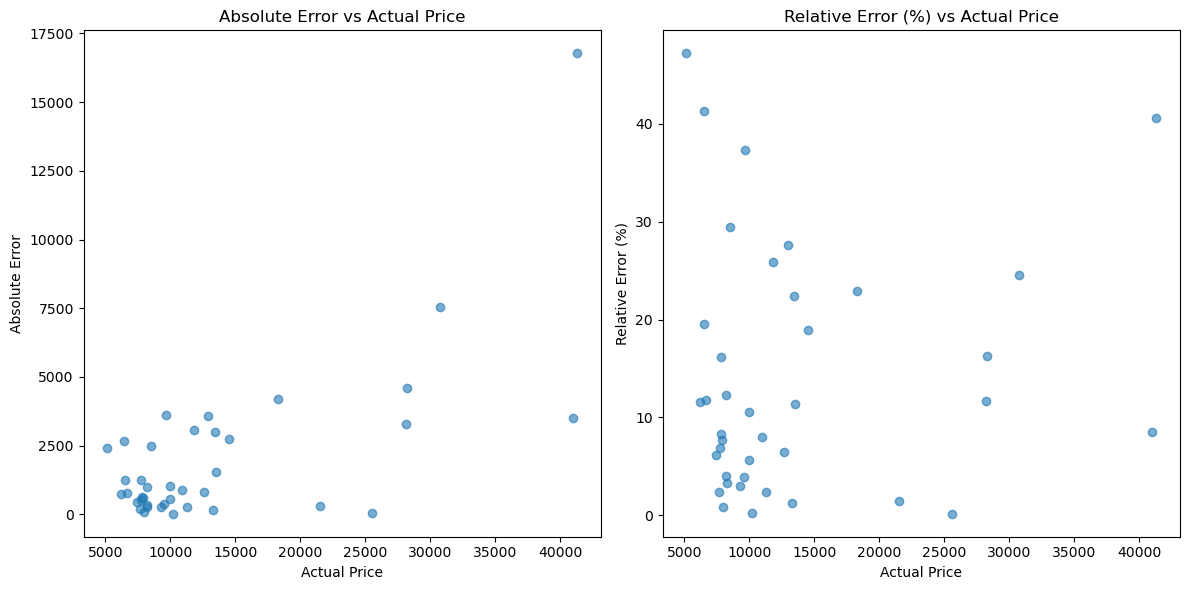

In [12]:
# Create error analysis dataframe
error_df = pd.DataFrame({
    'Actual': final_model['y_test'].flatten(),
    'Predicted': final_model['y_pred'].flatten(),
    'Error': residuals.flatten(),
    'Abs_Error': np.abs(residuals.flatten()),
    'Squared_Error': residuals.flatten() ** 2,
    'Rel_Error_Pct': (np.abs(residuals.flatten()) / final_model['y_test'].flatten()) * 100
})

# Find the worst predictions
print("Worst Predictions (Highest Errors):")
display(error_df.sort_values('Squared_Error', ascending=False).head(10))

# Error statistics
print("\nError Distribution Statistics:")
print(f"Mean Absolute Error: {error_df['Abs_Error'].mean():.2f}")
print(f"Median Absolute Error: {error_df['Abs_Error'].median():.2f}")
print(f"Mean Relative Error: {error_df['Rel_Error_Pct'].mean():.2f}%")
print(f"Median Relative Error: {error_df['Rel_Error_Pct'].median():.2f}%")
print(f"90th Percentile Error: {np.percentile(error_df['Abs_Error'], 90):.2f}")
print(f"95th Percentile Error: {np.percentile(error_df['Abs_Error'], 95):.2f}")

# Check if errors are correlated with price
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(error_df['Actual'], error_df['Abs_Error'], alpha=0.6)
plt.title('Absolute Error vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Absolute Error')

plt.subplot(1, 2, 2)
plt.scatter(error_df['Actual'], error_df['Rel_Error_Pct'], alpha=0.6)
plt.title('Relative Error (%) vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Relative Error (%)')
plt.tight_layout()
plt.show()